# [LAB-06] 캡스톤 (1) - MPG 데이터셋 (ADsP 기출)

1. 각 문제의 질문을 읽고, **어떤 그래프가 답을 찾기에 적절한지 스스로 판단**하여 직접 시각화하세요.
2. 그래프를 보고 객관식 보기 중 정답을 고르세요.

## 준비작업

### 1. 라이브러리 참조

In [56]:
from jussam import load_data
from helper import my_plot, my_qtcheck
from pandas import pivot_table, DataFrame
import numpy as np

### 2. 데이터셋 불러오기

In [2]:
origin = load_data("mpg")
origin.info()
origin.head()

📚 1999년과 2008년에 미국 EPA에서 조사하여 발표한 자동차 주요 모델별 연비 데이터 (출처: ADsP 기출 / R 내장 데이터)

    field         description
--  ------------  -------------------------------------------------------------
 0  manufacturer  자동차 제조사 (문자열)
 1  model         자동차 모델명 (문자열)
 2  displ         자동차 배기량 (연속형)
 3  year          제조년도 (연속형)
 4  cyl           엔진 실린더 수 (범주형)
 5  trans         자동차 트랜스미션 종류 (범주형)
 6  drv           자동차 구동 방식 (범주형). f=전륜구동, r=후륜구동, 4=사륜구동
 7  cty           도심 연비 (마일/갤론)
 8  hwy           고속도로 연비 (마일/갤론)
 9  fl            연료 종류 (범주형)
10  class         자동차 분류 (범주형)

<class 'pandas.DataFrame'>
RangeIndex: 234 entries, 1 to 234
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   manufacturer  234 non-null    str    
 1   model         234 non-null    str    
 2   displ         234 non-null    float64
 3   year          234 non-null    int64  
 4   cyl           234 non-null    int64  
 5   trans         234 non-null    s

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),f,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),f,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),f,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),f,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),f,16,26,p,compact


### 3. 데이터 전처리

- 구동방식 컬럼 값을 이해하기 쉬운 값으로 변환

In [3]:
df = origin.copy()
df["drv"] = df["drv"].map({"f": "전륜구동", "r": "후륜구동", "4": "4륜구동"})
df.head()

,manufacturer,model,displ,year,cyl,trans,drv,cty,hwy,fl,class
id,,,,,,,,,,,
1,audi,a4,1.800,1999,4,auto(l5),전륜구동,18,29,p,compact
2,audi,a4,1.800,1999,4,manual(m5),전륜구동,21,29,p,compact
3,audi,a4,2.000,2008,4,manual(m6),전륜구동,20,31,p,compact
4,audi,a4,2.000,2008,4,auto(av),전륜구동,21,30,p,compact
5,audi,a4,2.800,1999,6,auto(l5),전륜구동,16,26,p,compact


## 문제 1. 출시 차량 수가 가장 많은 제조사는?

① audi  ② dodge  ③ toyota  ④ volkswagen

> 💡 **힌트**: 막대그래프 (제조사별 빈도)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


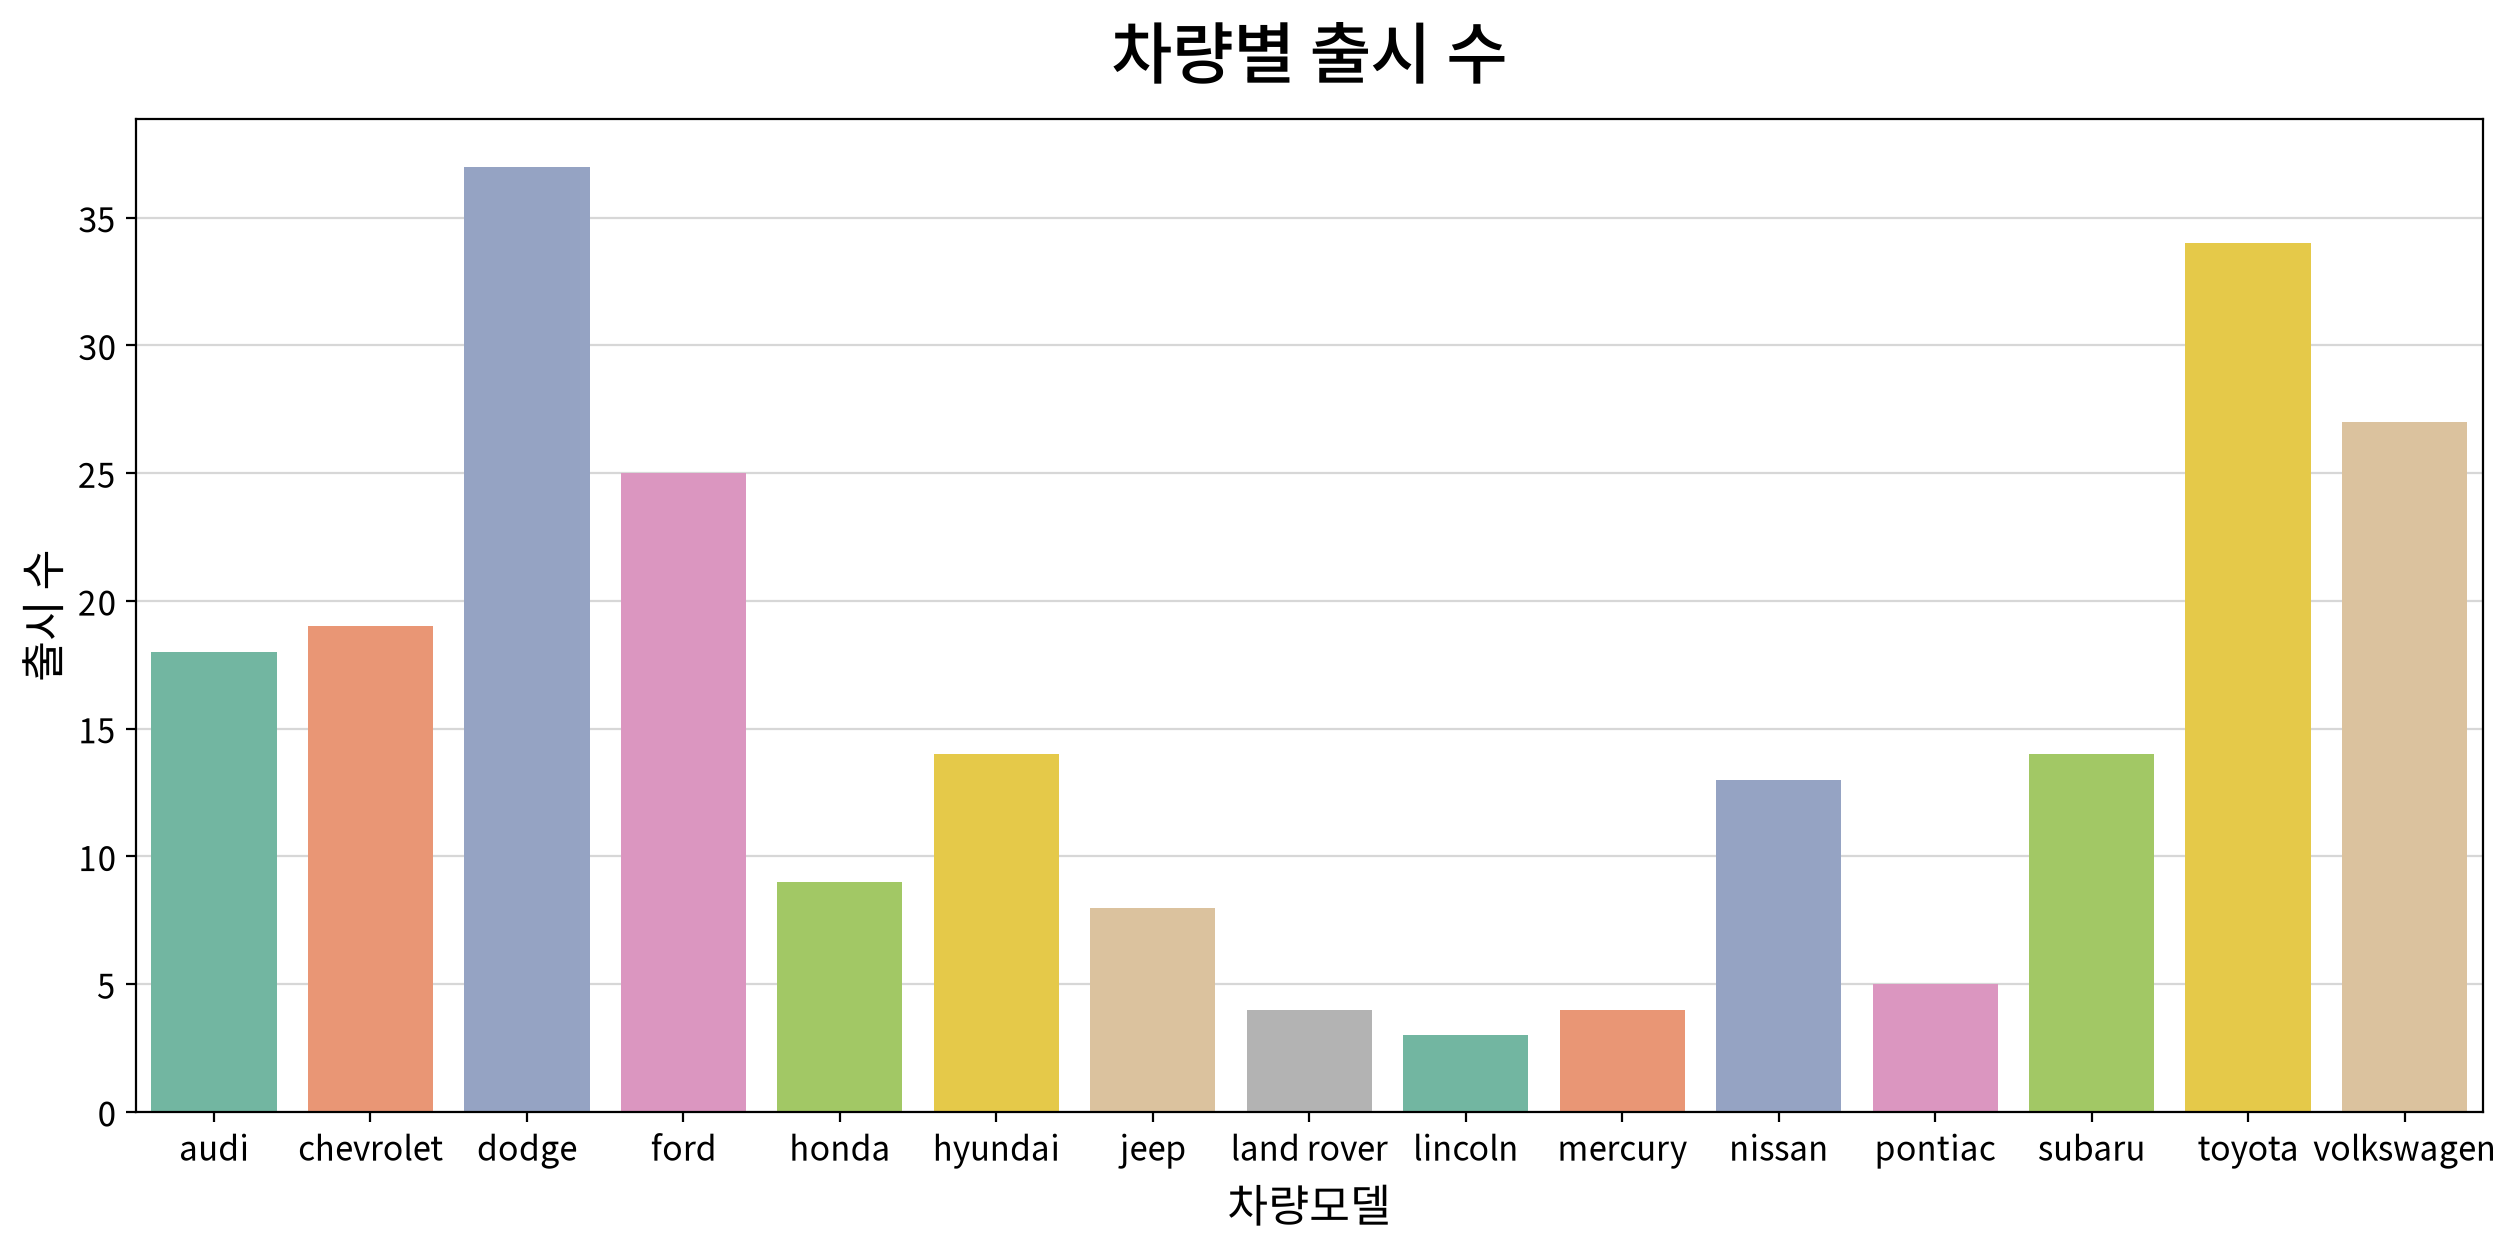

In [4]:
# 막대그래프 그리기 (모듈)
my_plot.countplot(df, x='manufacturer', palette="Set2", title="차량별 출시 수", xlabel='차량모델', ylabel='출시 수')

## 정답
#### 그래프에 보이는 것과 같이 dodge차량이 1등, toyota차량이 2등 volkswagen 차량이 3등 순이다.

## 문제 2. 차종(`class`) 중 가장 많은 비중을 차지하는 종류는?

① compact  ② midsize  ③ suv  ④ pickup

> 💡 **힌트**: 막대그래프 또는 원그래프 (차종별 빈도)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


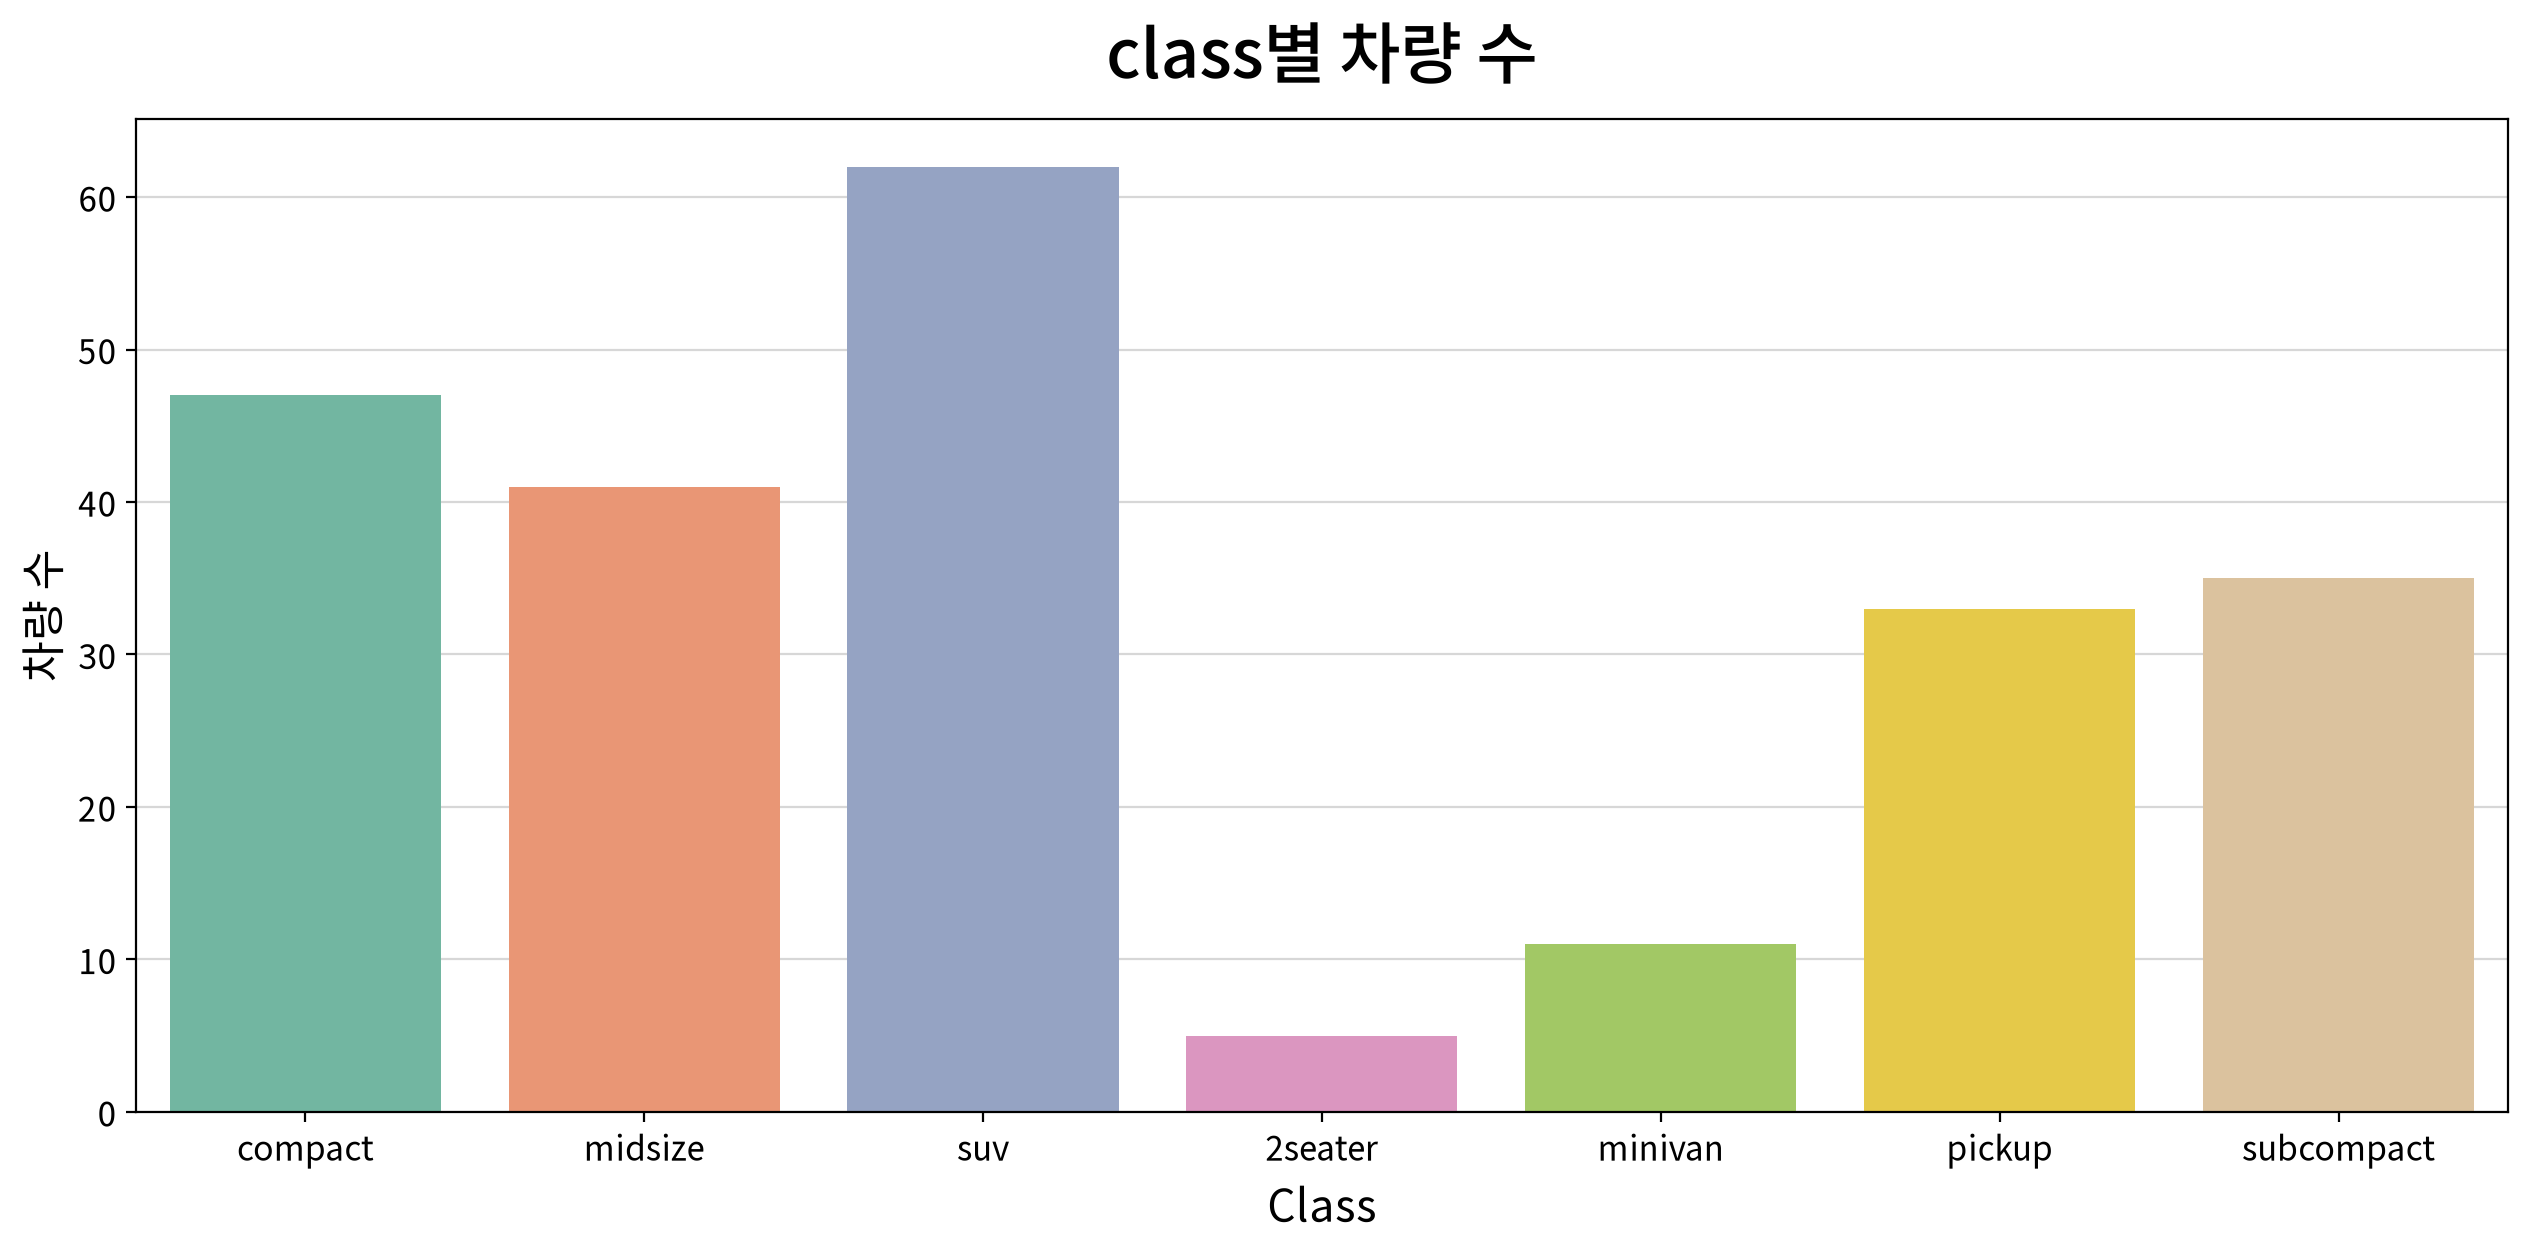

In [5]:
# 막대그래프 
my_plot.countplot(df, x='class', palette='Set2', title='class별 차량 수', xlabel='Class', ylabel='차량 수')

## 정답
#### SUV 차량이 1등으로 가장 비중이 높음

## 문제 3. 구동방식(`drv`) 중 차량 수가 가장 적은 방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 동일

> 💡 **힌트**: 막대그래프 (구동방식별 빈도)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


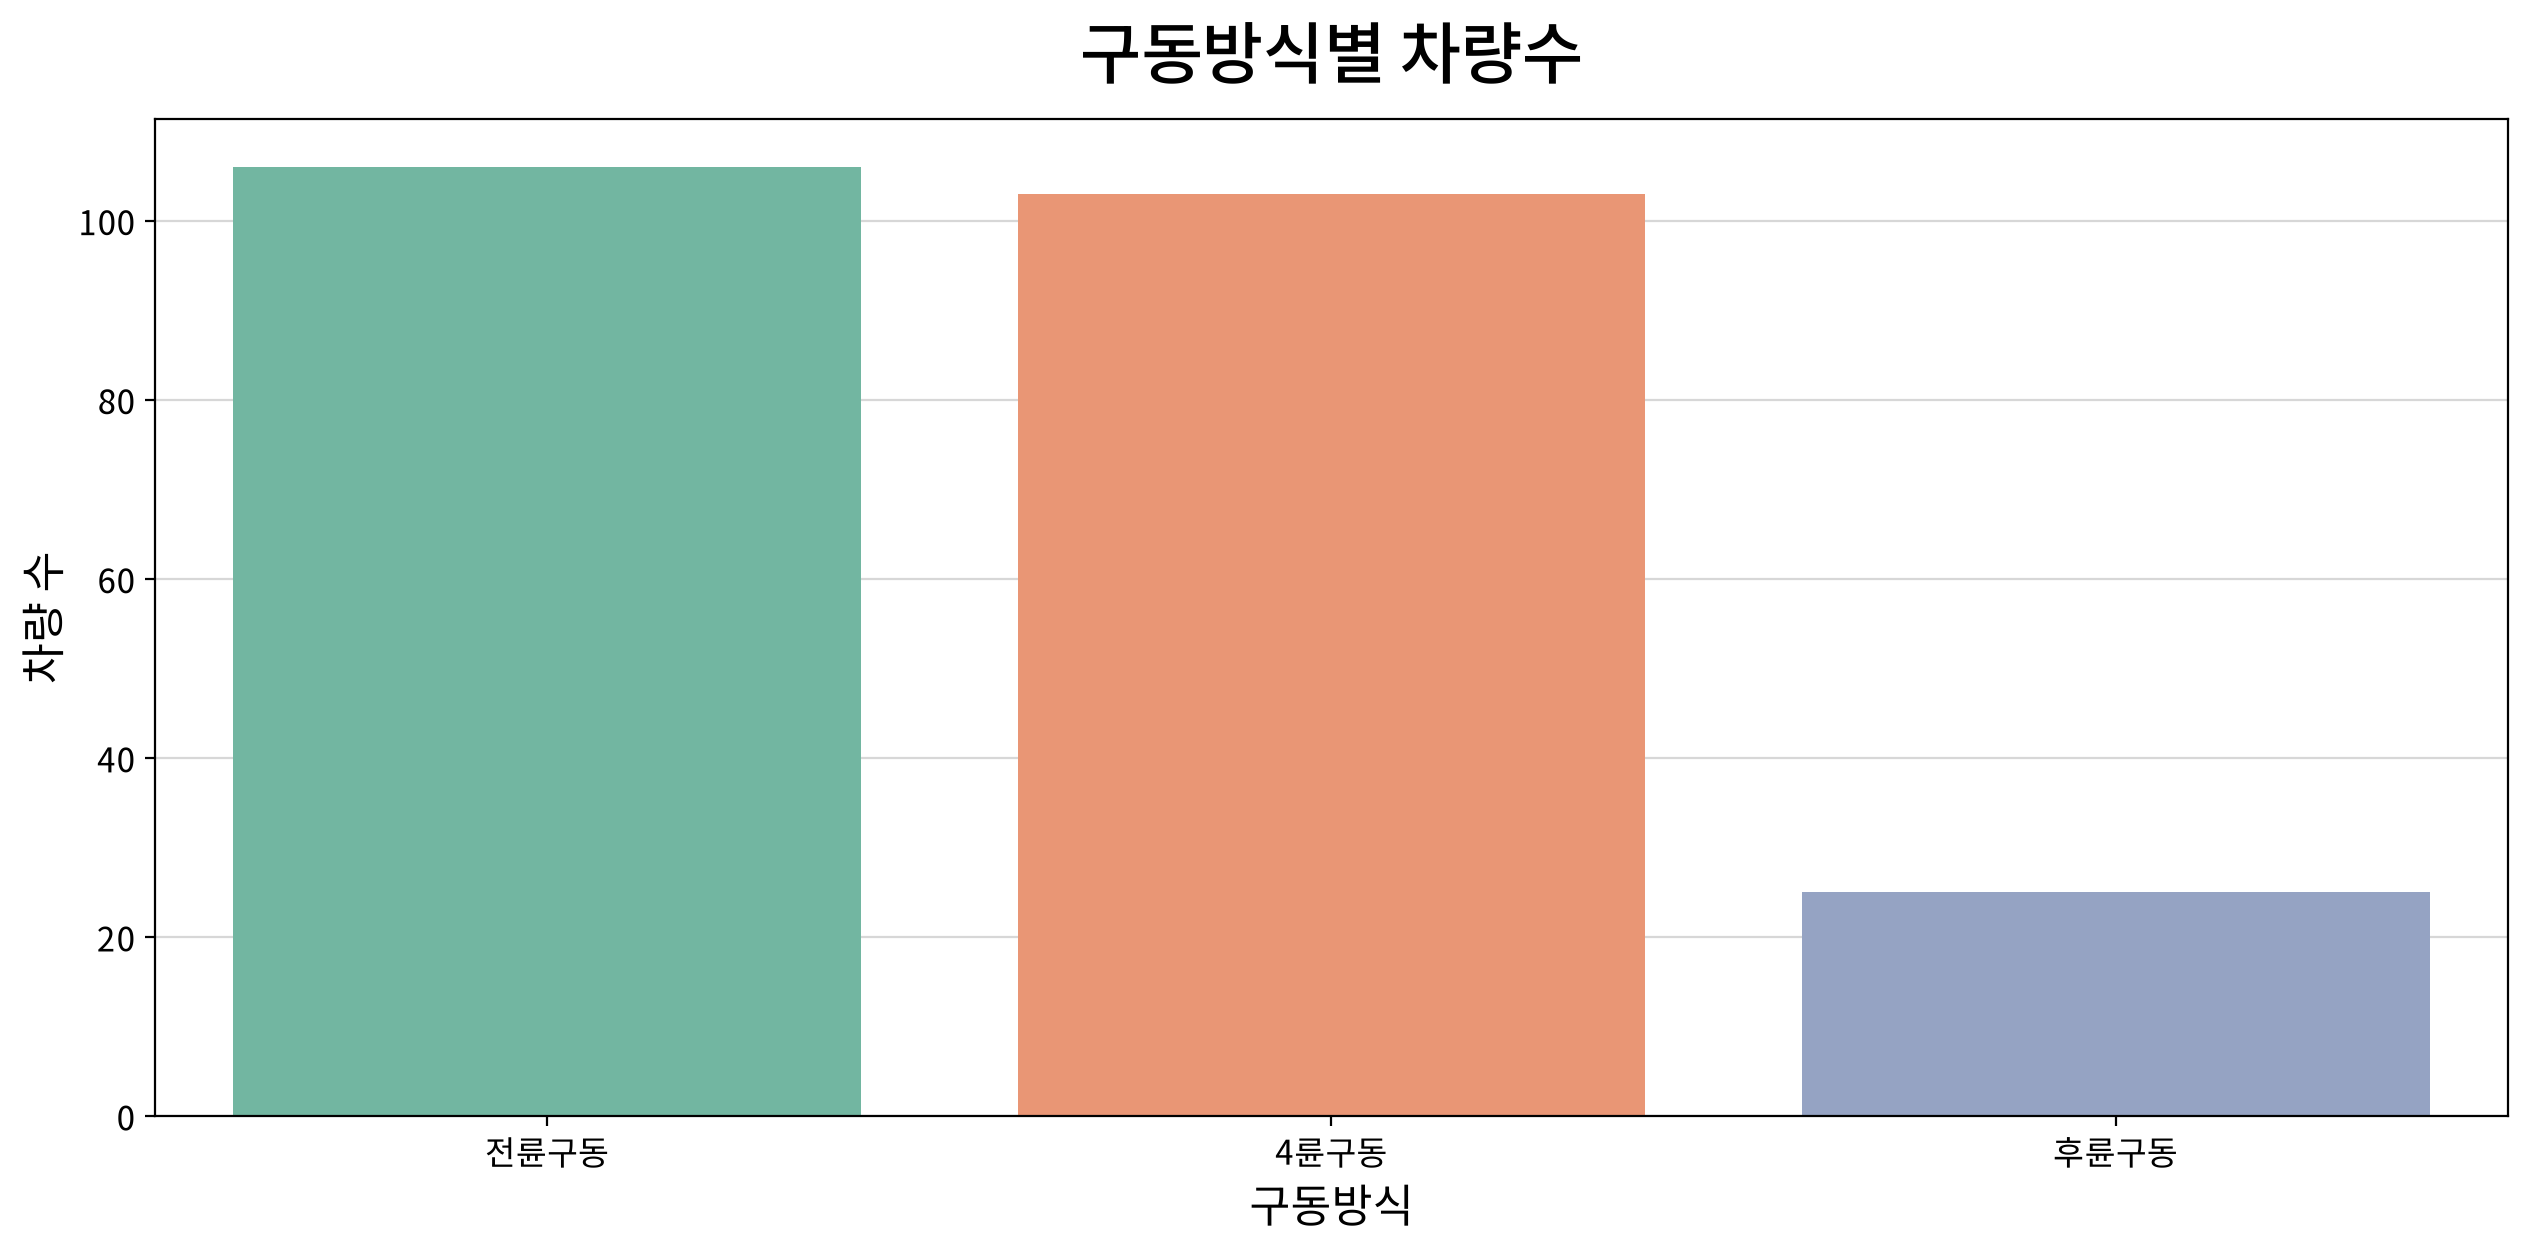

In [6]:
my_plot.countplot(df, x='drv', title='구동방식별 차량수', xlabel='구동방식', ylabel='차량 수', palette='Set2')

## 정답
#### 그래프에 보이는 것과 같이 후륜구동이 제일 적음

## 문제 4. 도심 연비(`cty`) 평균이 가장 높은 구동방식은?

① 전륜구동  ② 4륜구동  ③ 후륜구동  ④ 모두 비슷

> 💡 **힌트**: 막대그래프 (구동방식별 cty 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


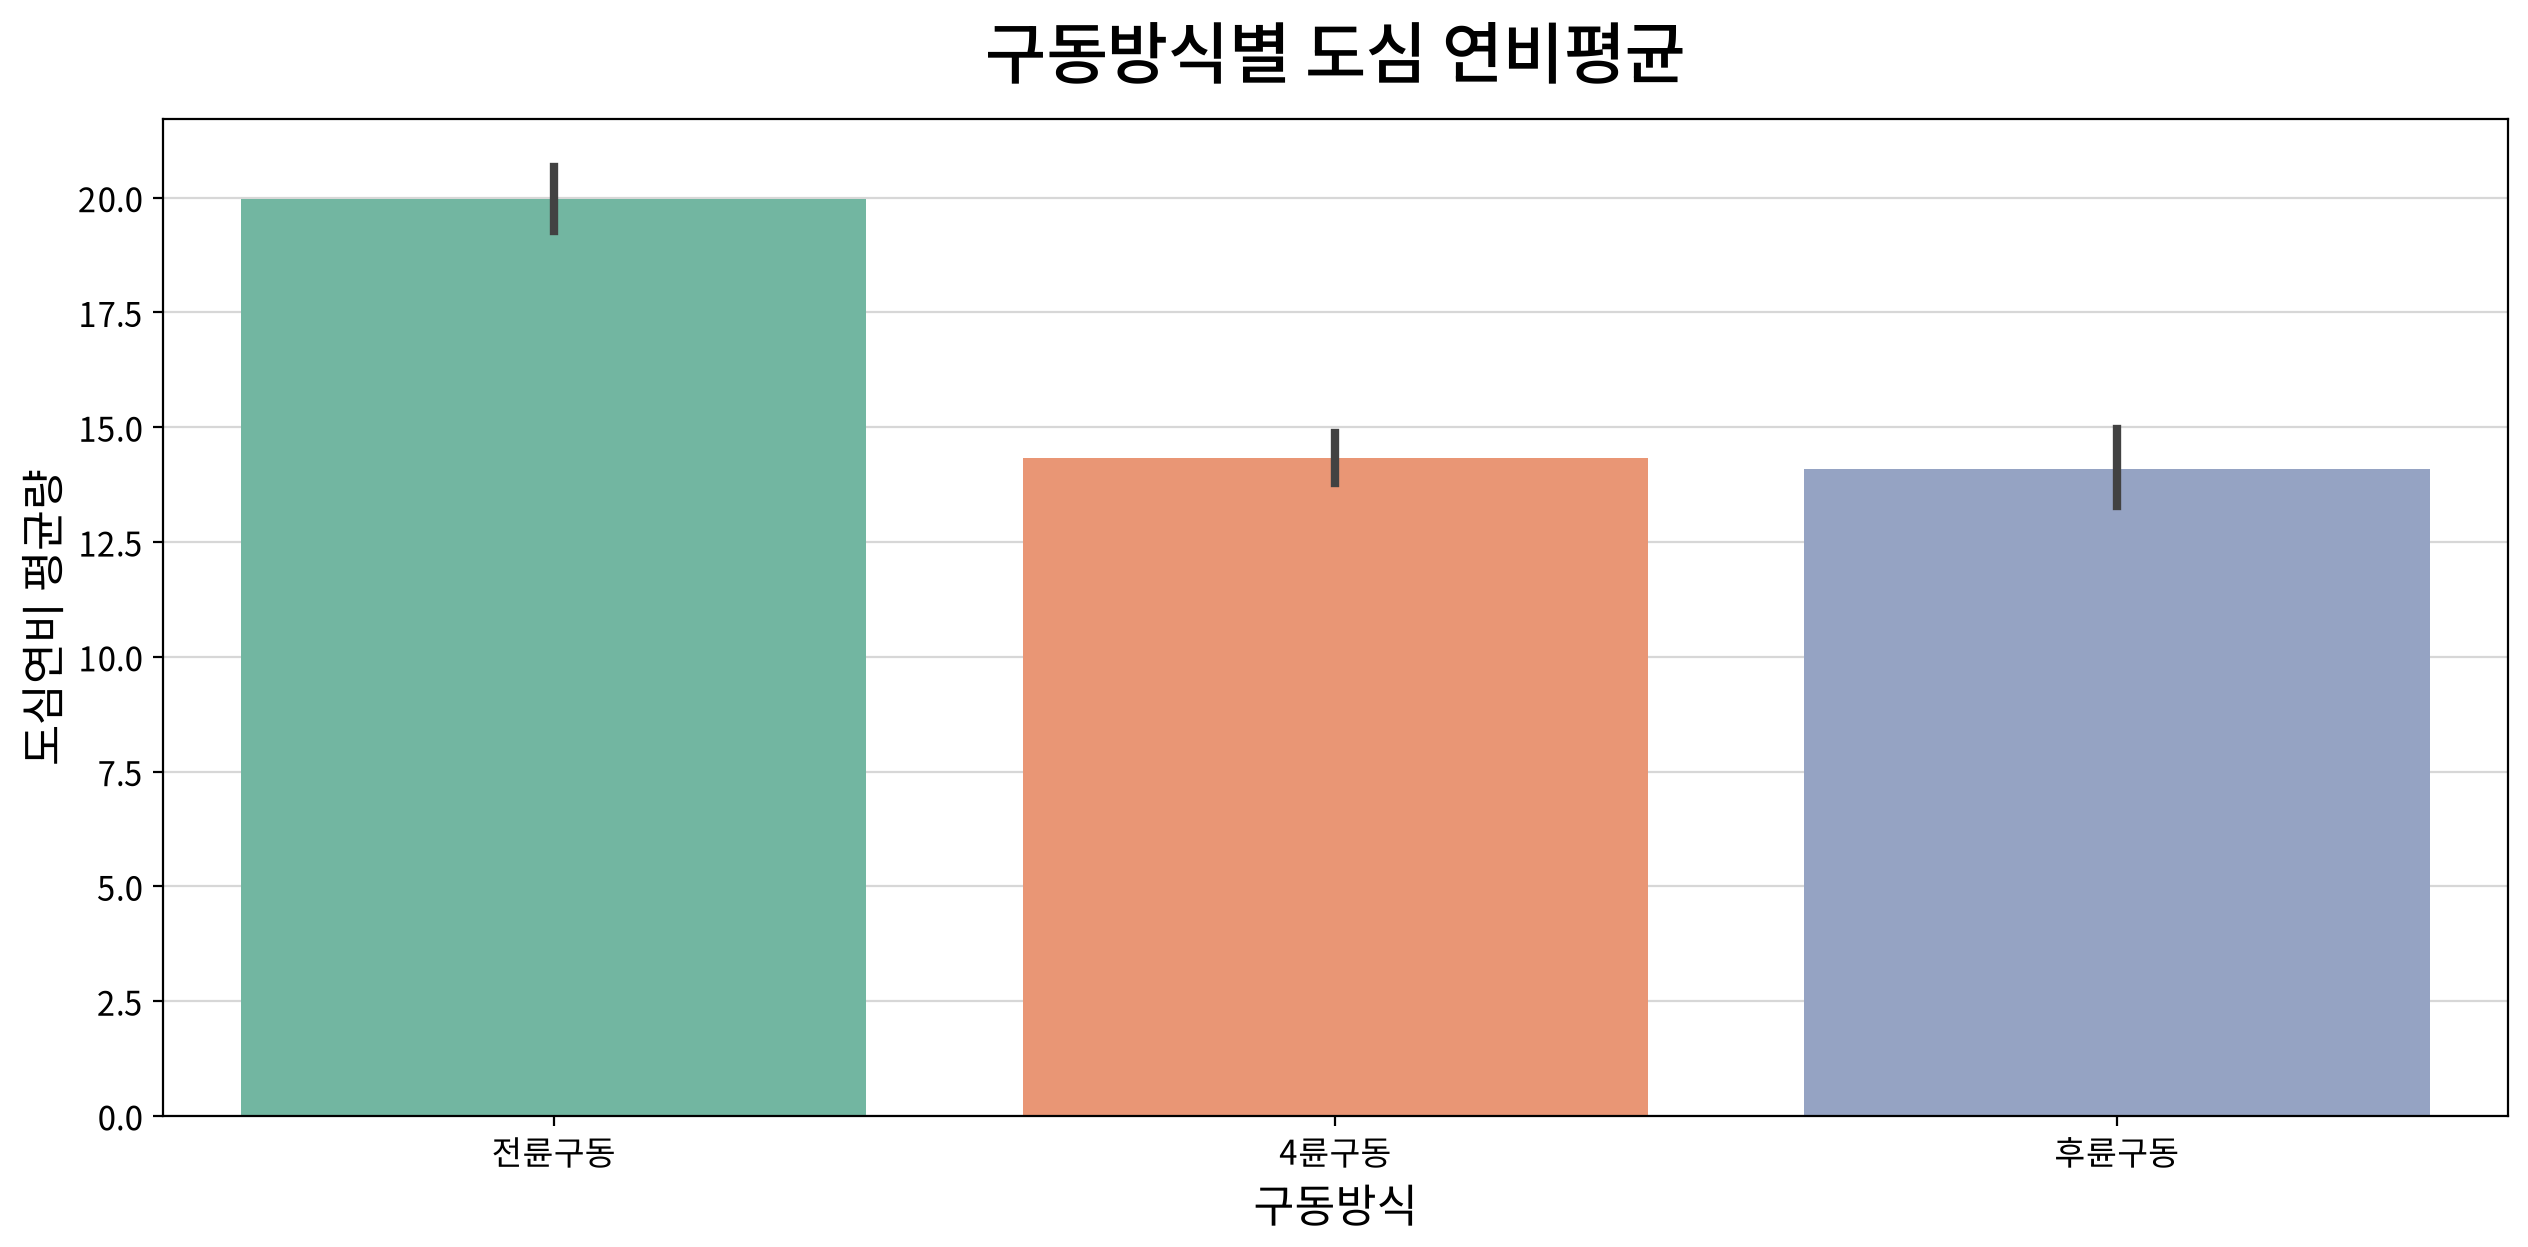

In [7]:
my_plot.barplot(df, x='drv', y='cty', estimator=np.mean, title='구동방식별 도심 연비평균', xlabel='구동방식', ylabel='도심연비 평균량', palette='Set2')

## 정답
#### 전륜구동이 제일 도심연비평균이 좋음

## 문제 5. 실린더 수(`cyl`)가 많아질수록 고속도로 연비(`hwy`)는 어떤 경향을 보이는가?

① 증가한다  ② 감소한다  ③ 관계가 없다  ④ U자 형태

> 💡 **힌트**: 막대그래프 (실린더 수별 hwy 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


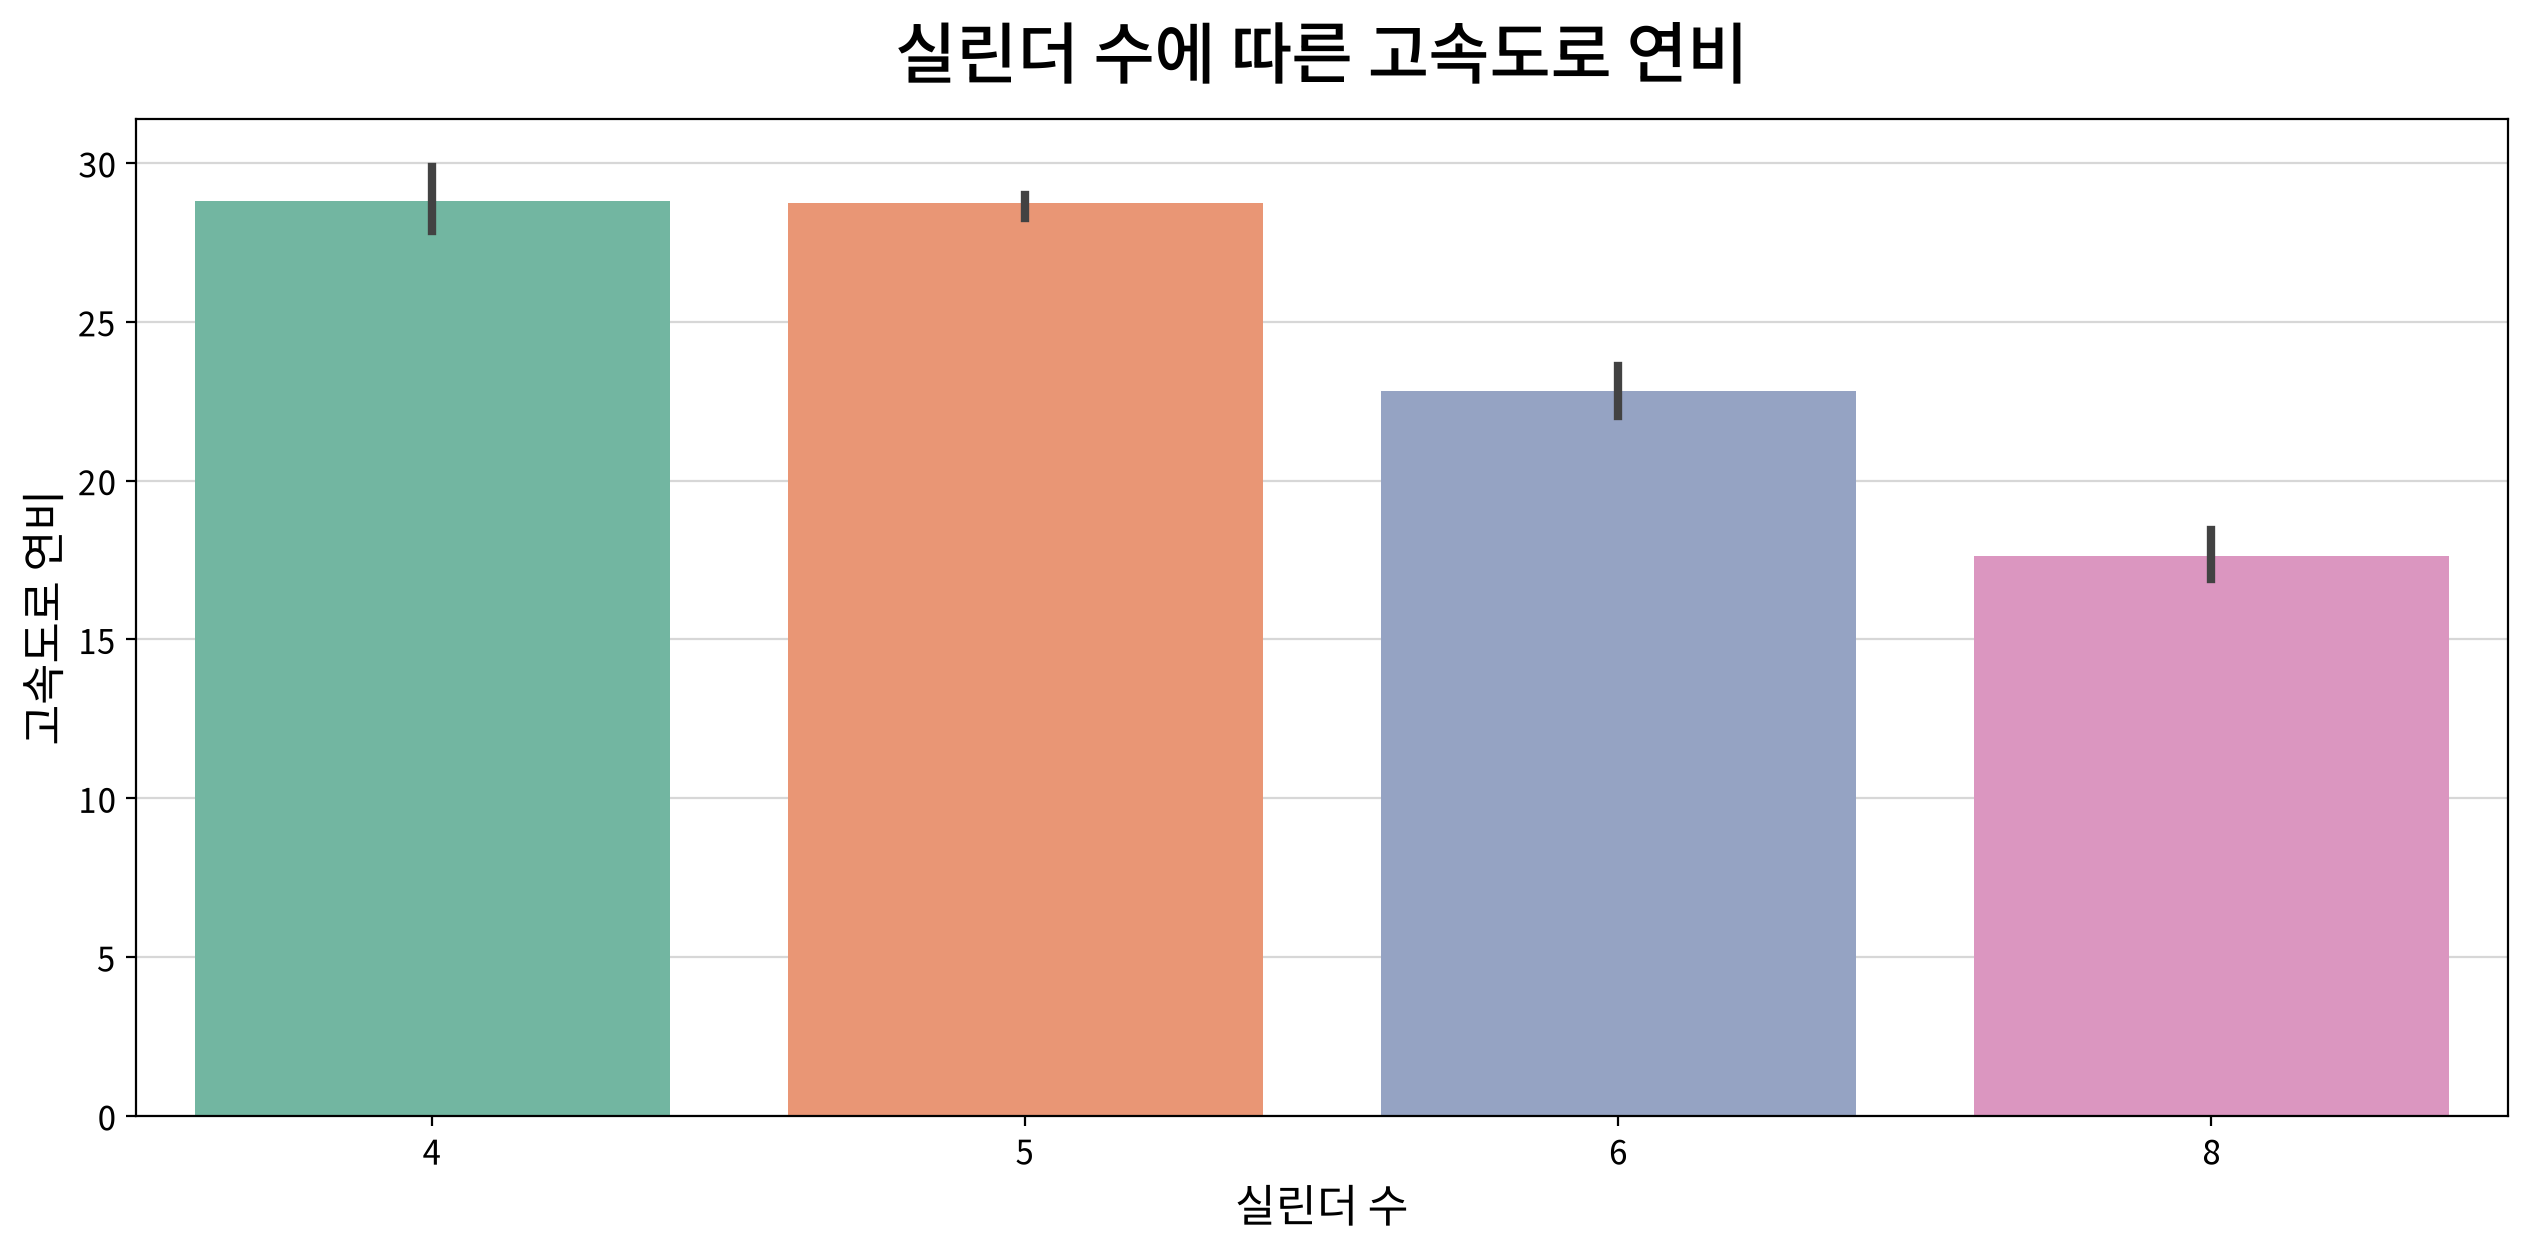

In [8]:
my_plot.barplot(df, x='cyl', y='hwy', estimator=np.mean, title='실린더 수에 따른 고속도로 연비', xlabel='실린더 수', ylabel='고속도로 연비', palette='Set2')

## 정답
#### 그래프에 보이듯 실린더 수가 많아질수록 고속도로 연비는 줄어든다. 하지만 4개,5개일때는 비슷하다

## 문제 6. 배기량(`displ`)과 고속도로 연비(`hwy`)는 어떤 상관관계를 가지는가?

① 양(+)의 상관  ② 음(−)의 상관  ③ 상관 없음  ④ 곡선(2차) 관계

> 💡 **힌트**: 산점도 (+ 추세선)

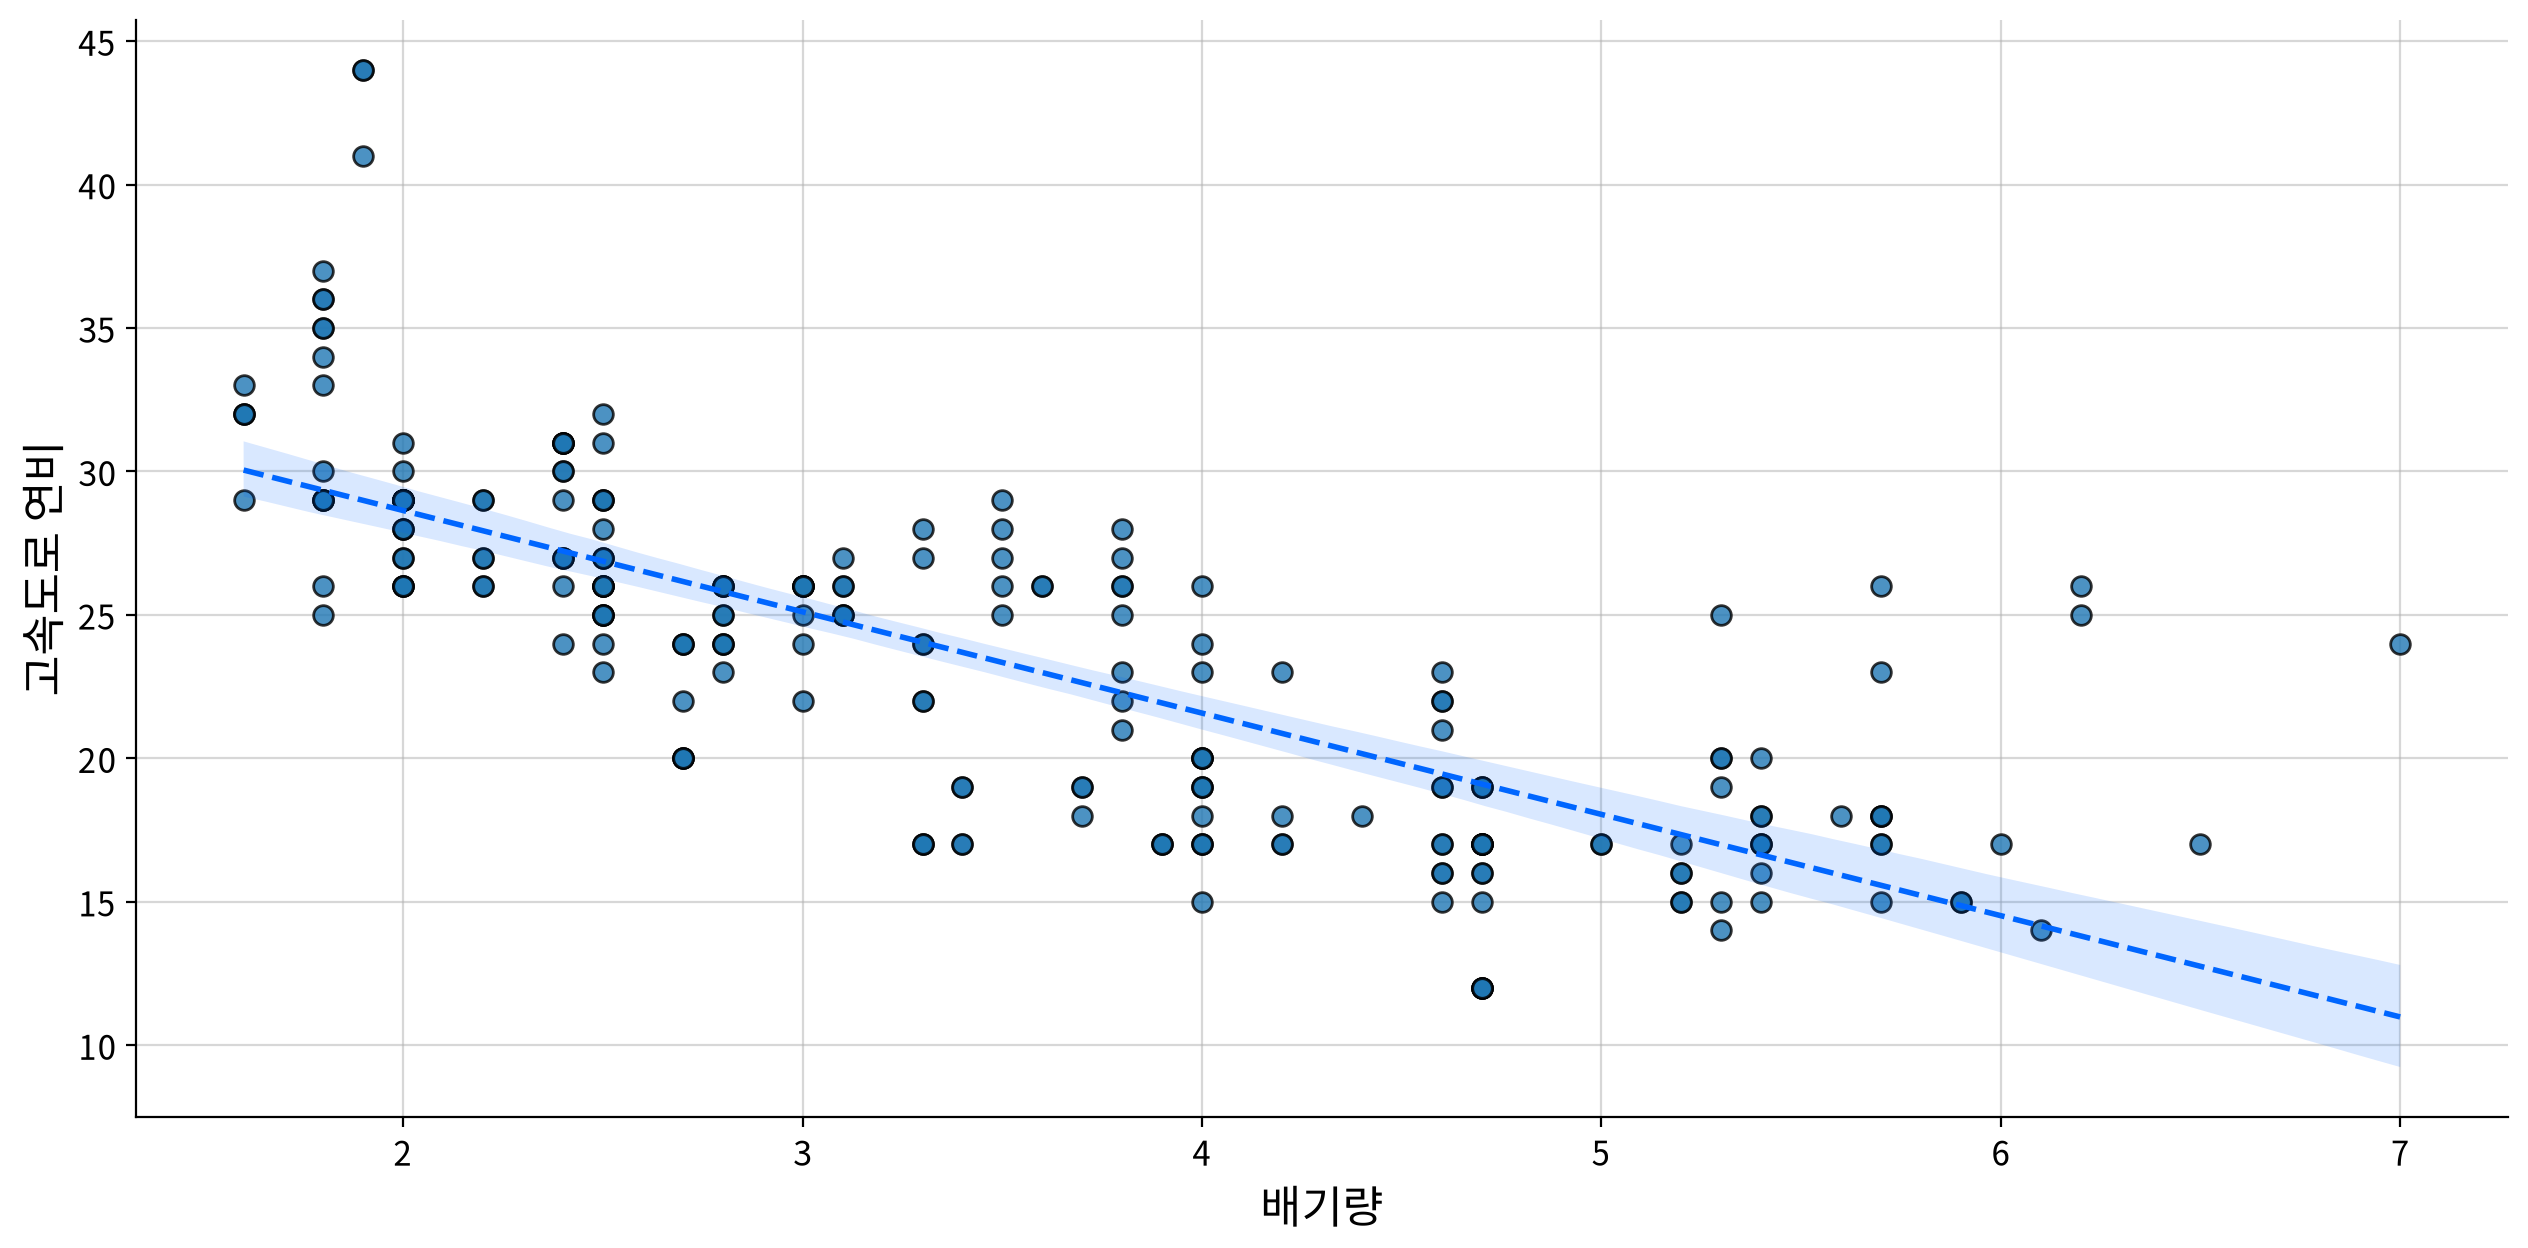

In [9]:
my_plot.lmplot(df, x='displ', y='hwy', markers='o', xlabel='배기량', ylabel='고속도로 연비', scatter_edgecolor='#000000', scatter_linewidths=1, scatter_size=50, linestyle='--', linecolor='#0066ff', linewidth=2)

## 정답
#### 배기량이 높아질수록 고속도로 연비는 안좋아지는 음의 상관관계가 있음

## 문제 7. 배기량(`displ`)과 더 강한(추세션의 기울기가 큰) 상관관계를 가지는 연비는?

① 도심 연비(cty)  ② 고속도로 연비(hwy)  ③ 둘이 완전히 동일  ④ 둘 다 상관 없음

> 💡 **힌트**: 산점도 2개를 비교 (+ 추세선)

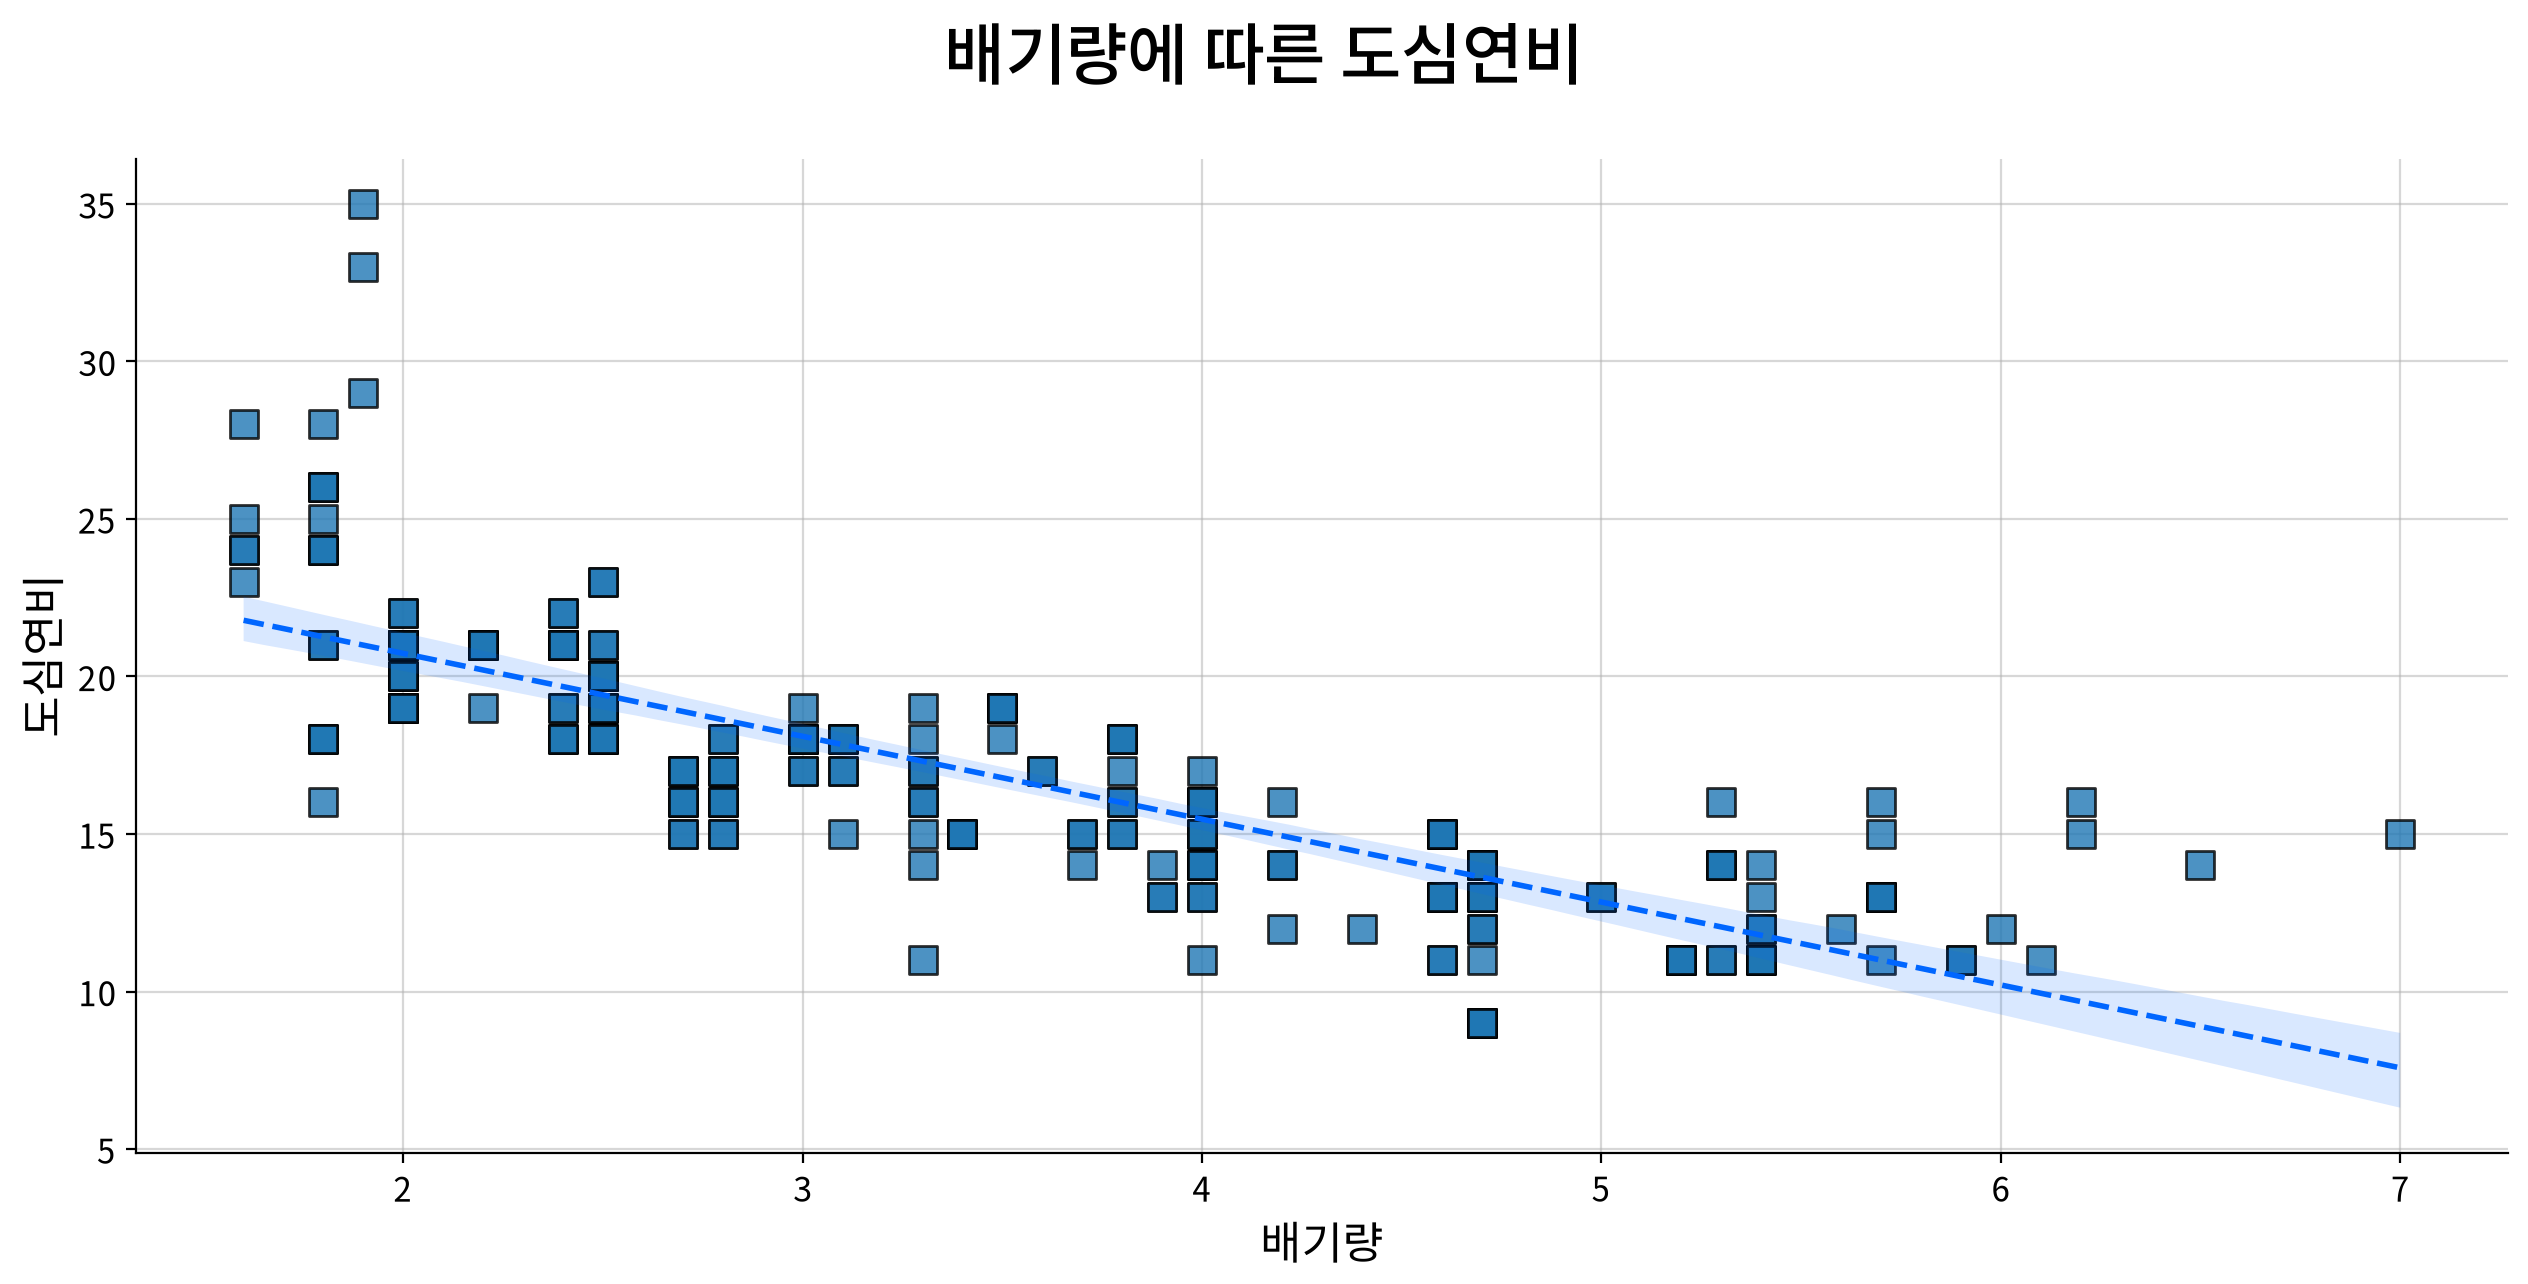

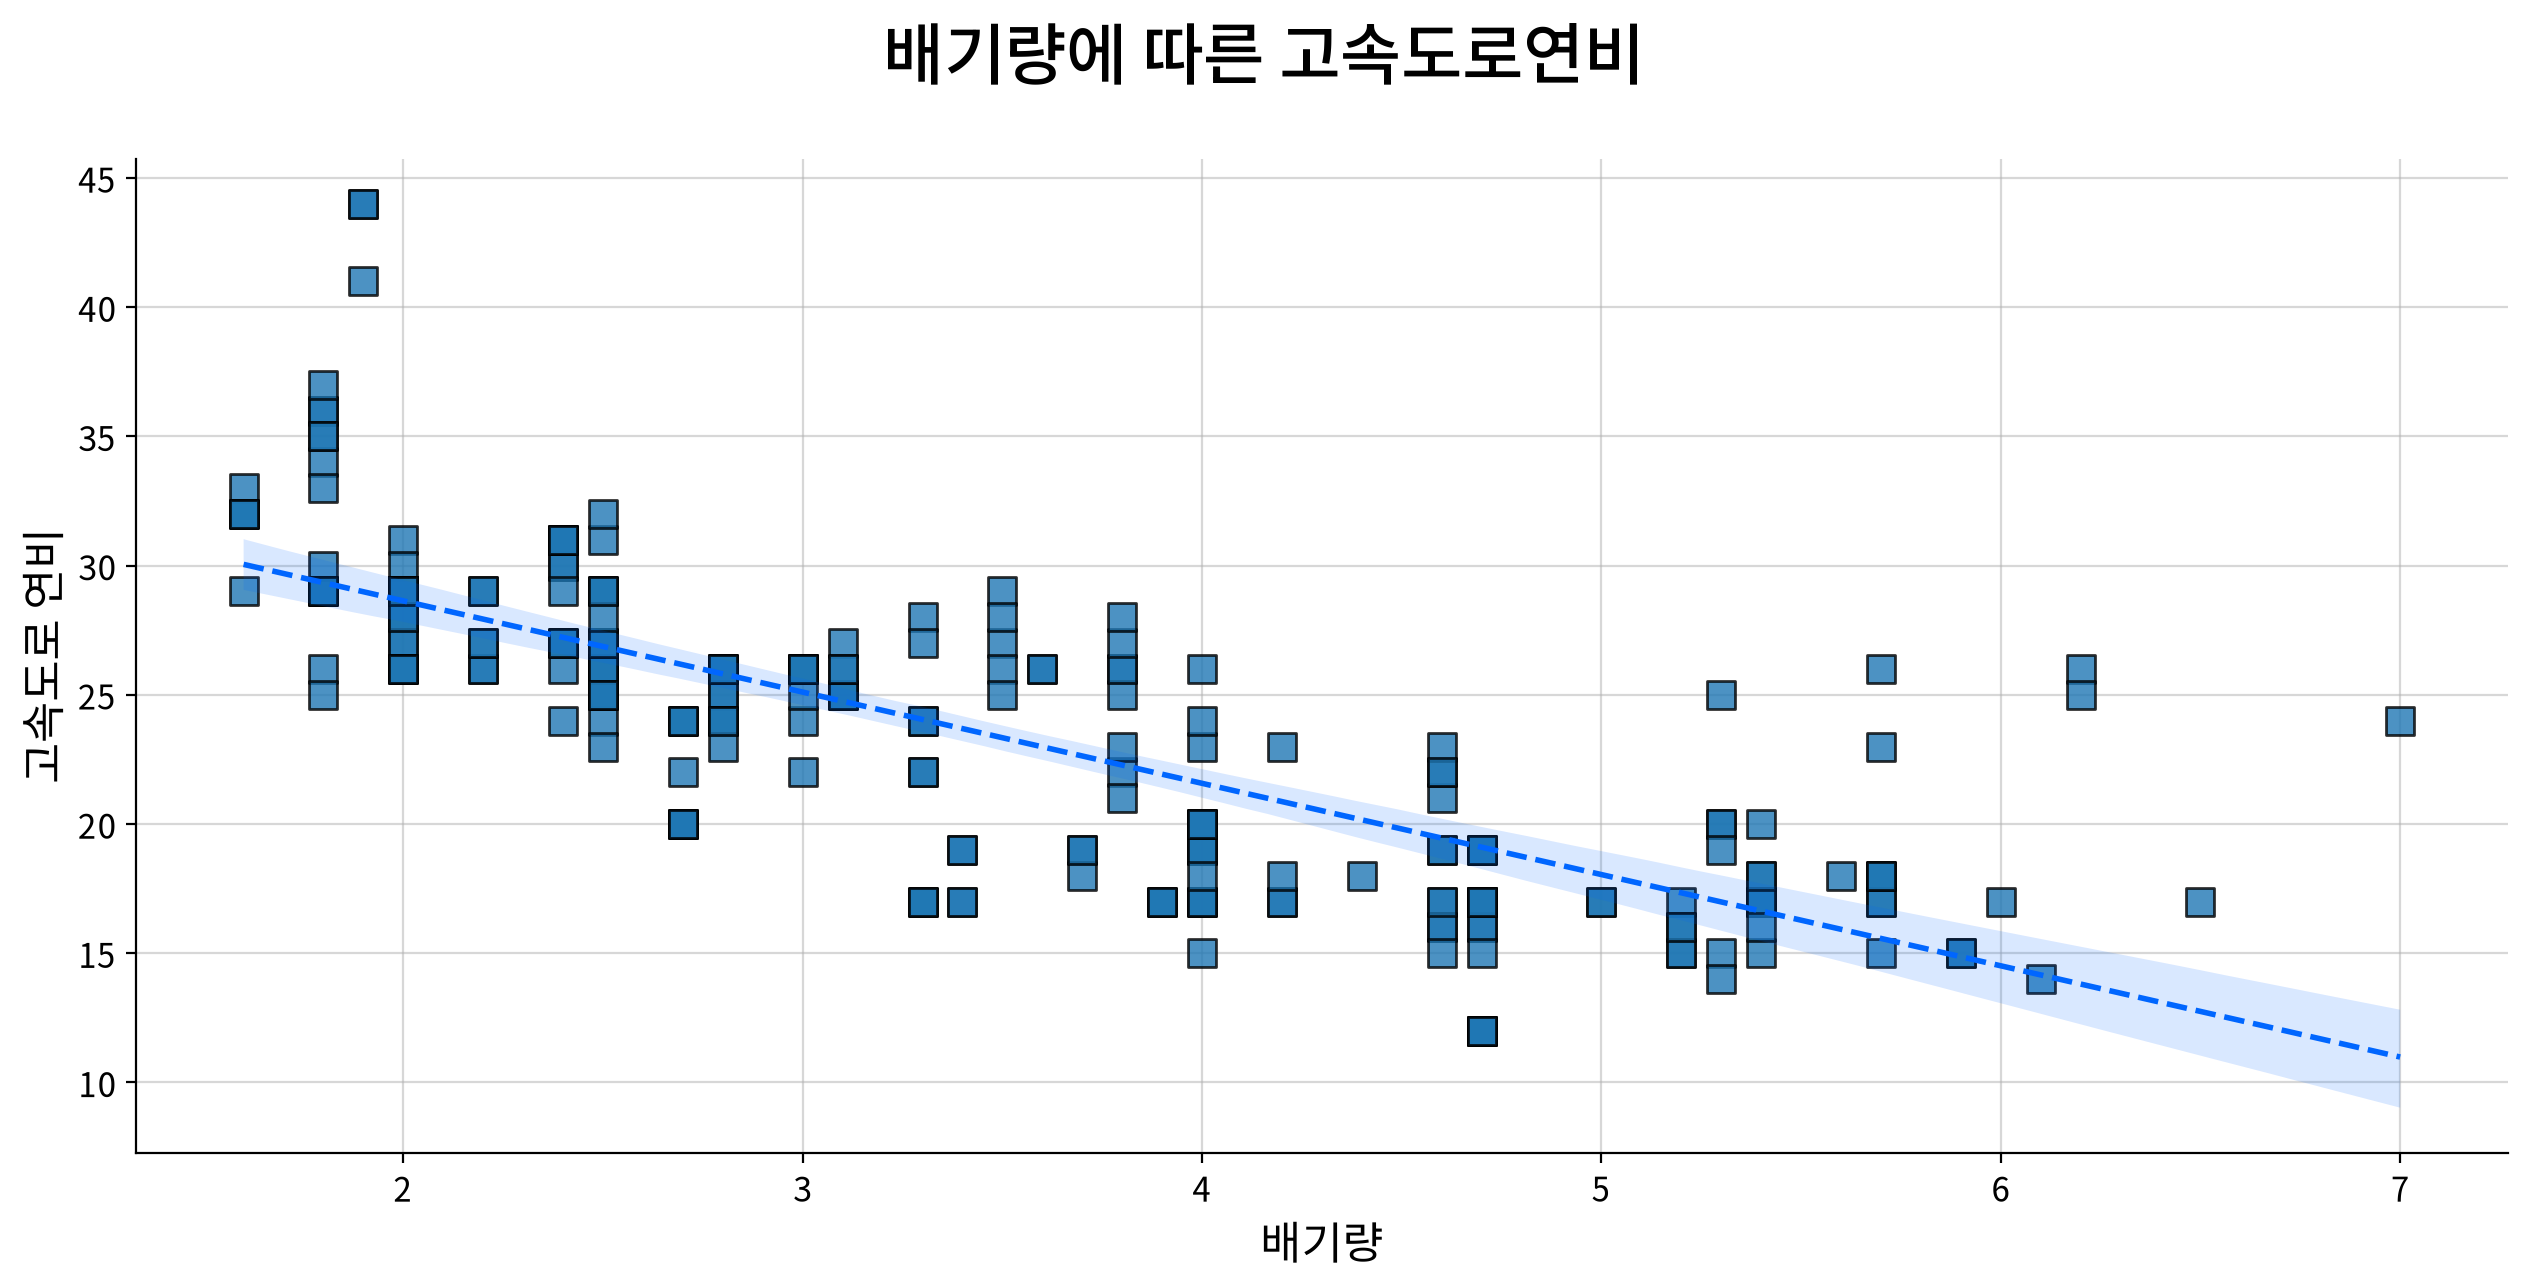

In [10]:
my_plot.lmplot(df, x='displ', y='cty', title='배기량에 따른 도심연비', xlabel='배기량', ylabel='도심연비', markers='s', scatter_size=100, scatter_edgecolor='#000000', linestyle='--',
               linewidth=2, linecolor='#0066ff', scatter_linewidths=1)
my_plot.lmplot(df, x='displ', y='hwy', title='배기량에 따른 고속도로연비', xlabel='배기량', ylabel='고속도로 연비', markers='s', scatter_edgecolor='#000000', scatter_linewidths=1, scatter_size=100,
               linestyle='--', linewidth=2, linecolor='#0066ff')

## 정답
#### 거의 동일하다고 보면 된다.

## 문제 8. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 낮은 종류는?

① suv  ② pickup  ③ minivan  ④ midsize

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


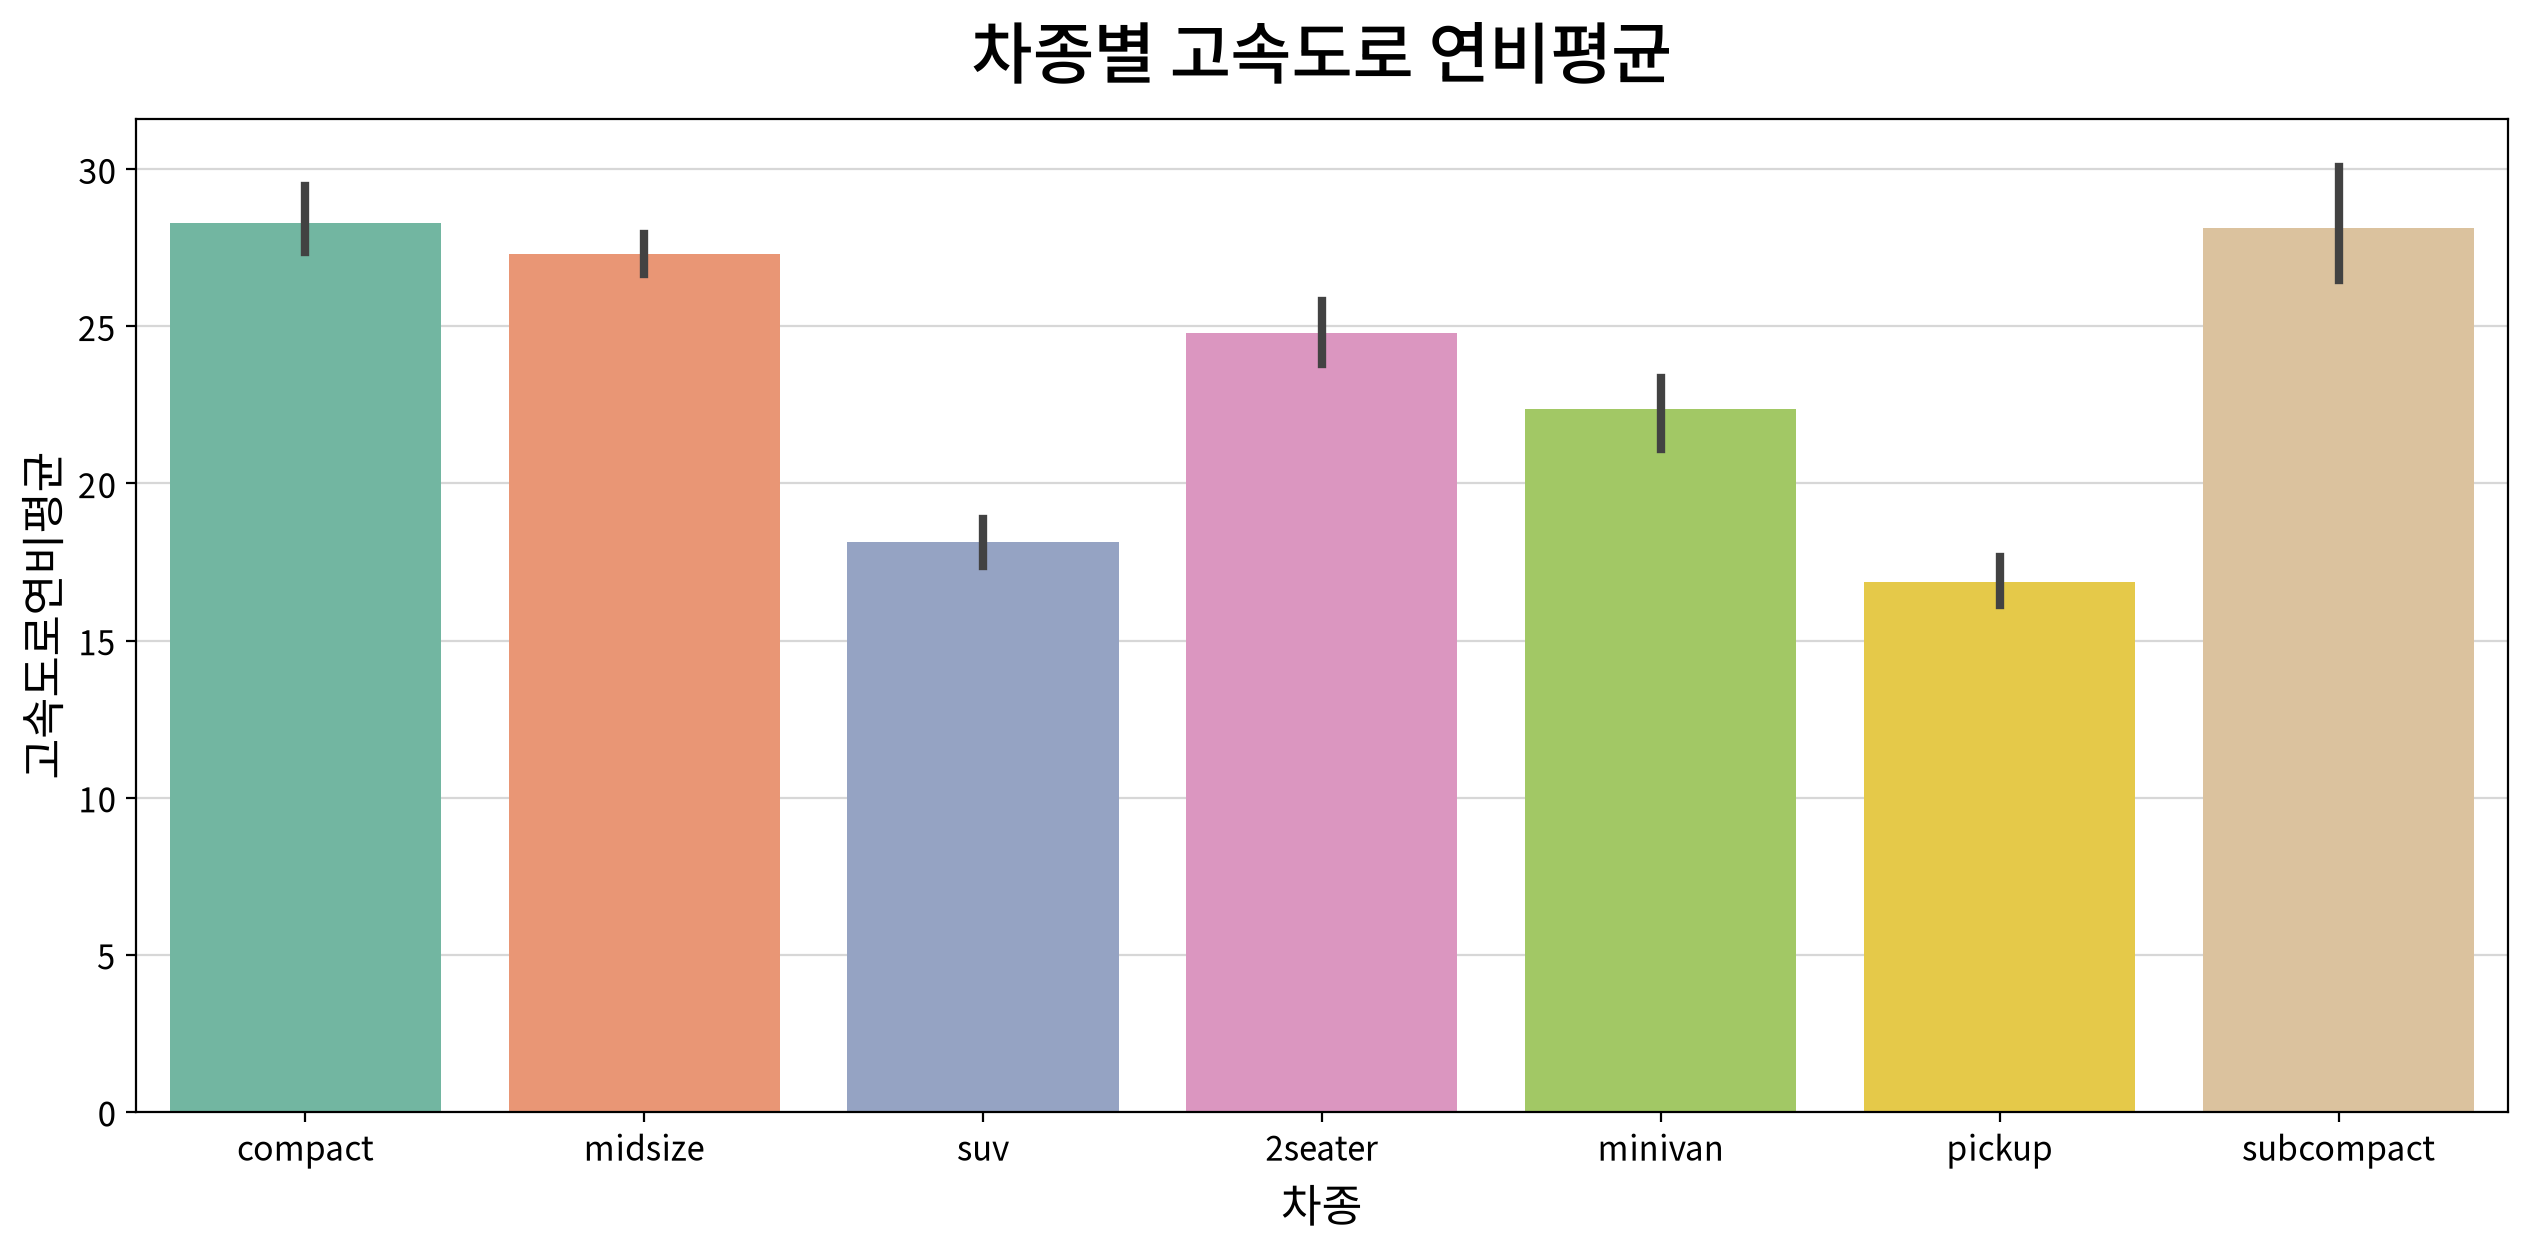

In [11]:
my_plot.barplot(df, x='class', y='hwy', estimator=np.mean, title='차종별 고속도로 연비평균', xlabel='차종', ylabel='고속도로연비평균', palette='Set2')

## 정답
#### 픽업차량이 제일 낮음

## 문제 9. 차종(`class`) 중 고속도로 연비(`hwy`) 평균이 가장 높은 종류는?

① compact  ② subcompact  ③ midsize  ④ 2seater

> 💡 **힌트**: 막대그래프 (차종별 hwy 평균, 내림차순 정렬)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


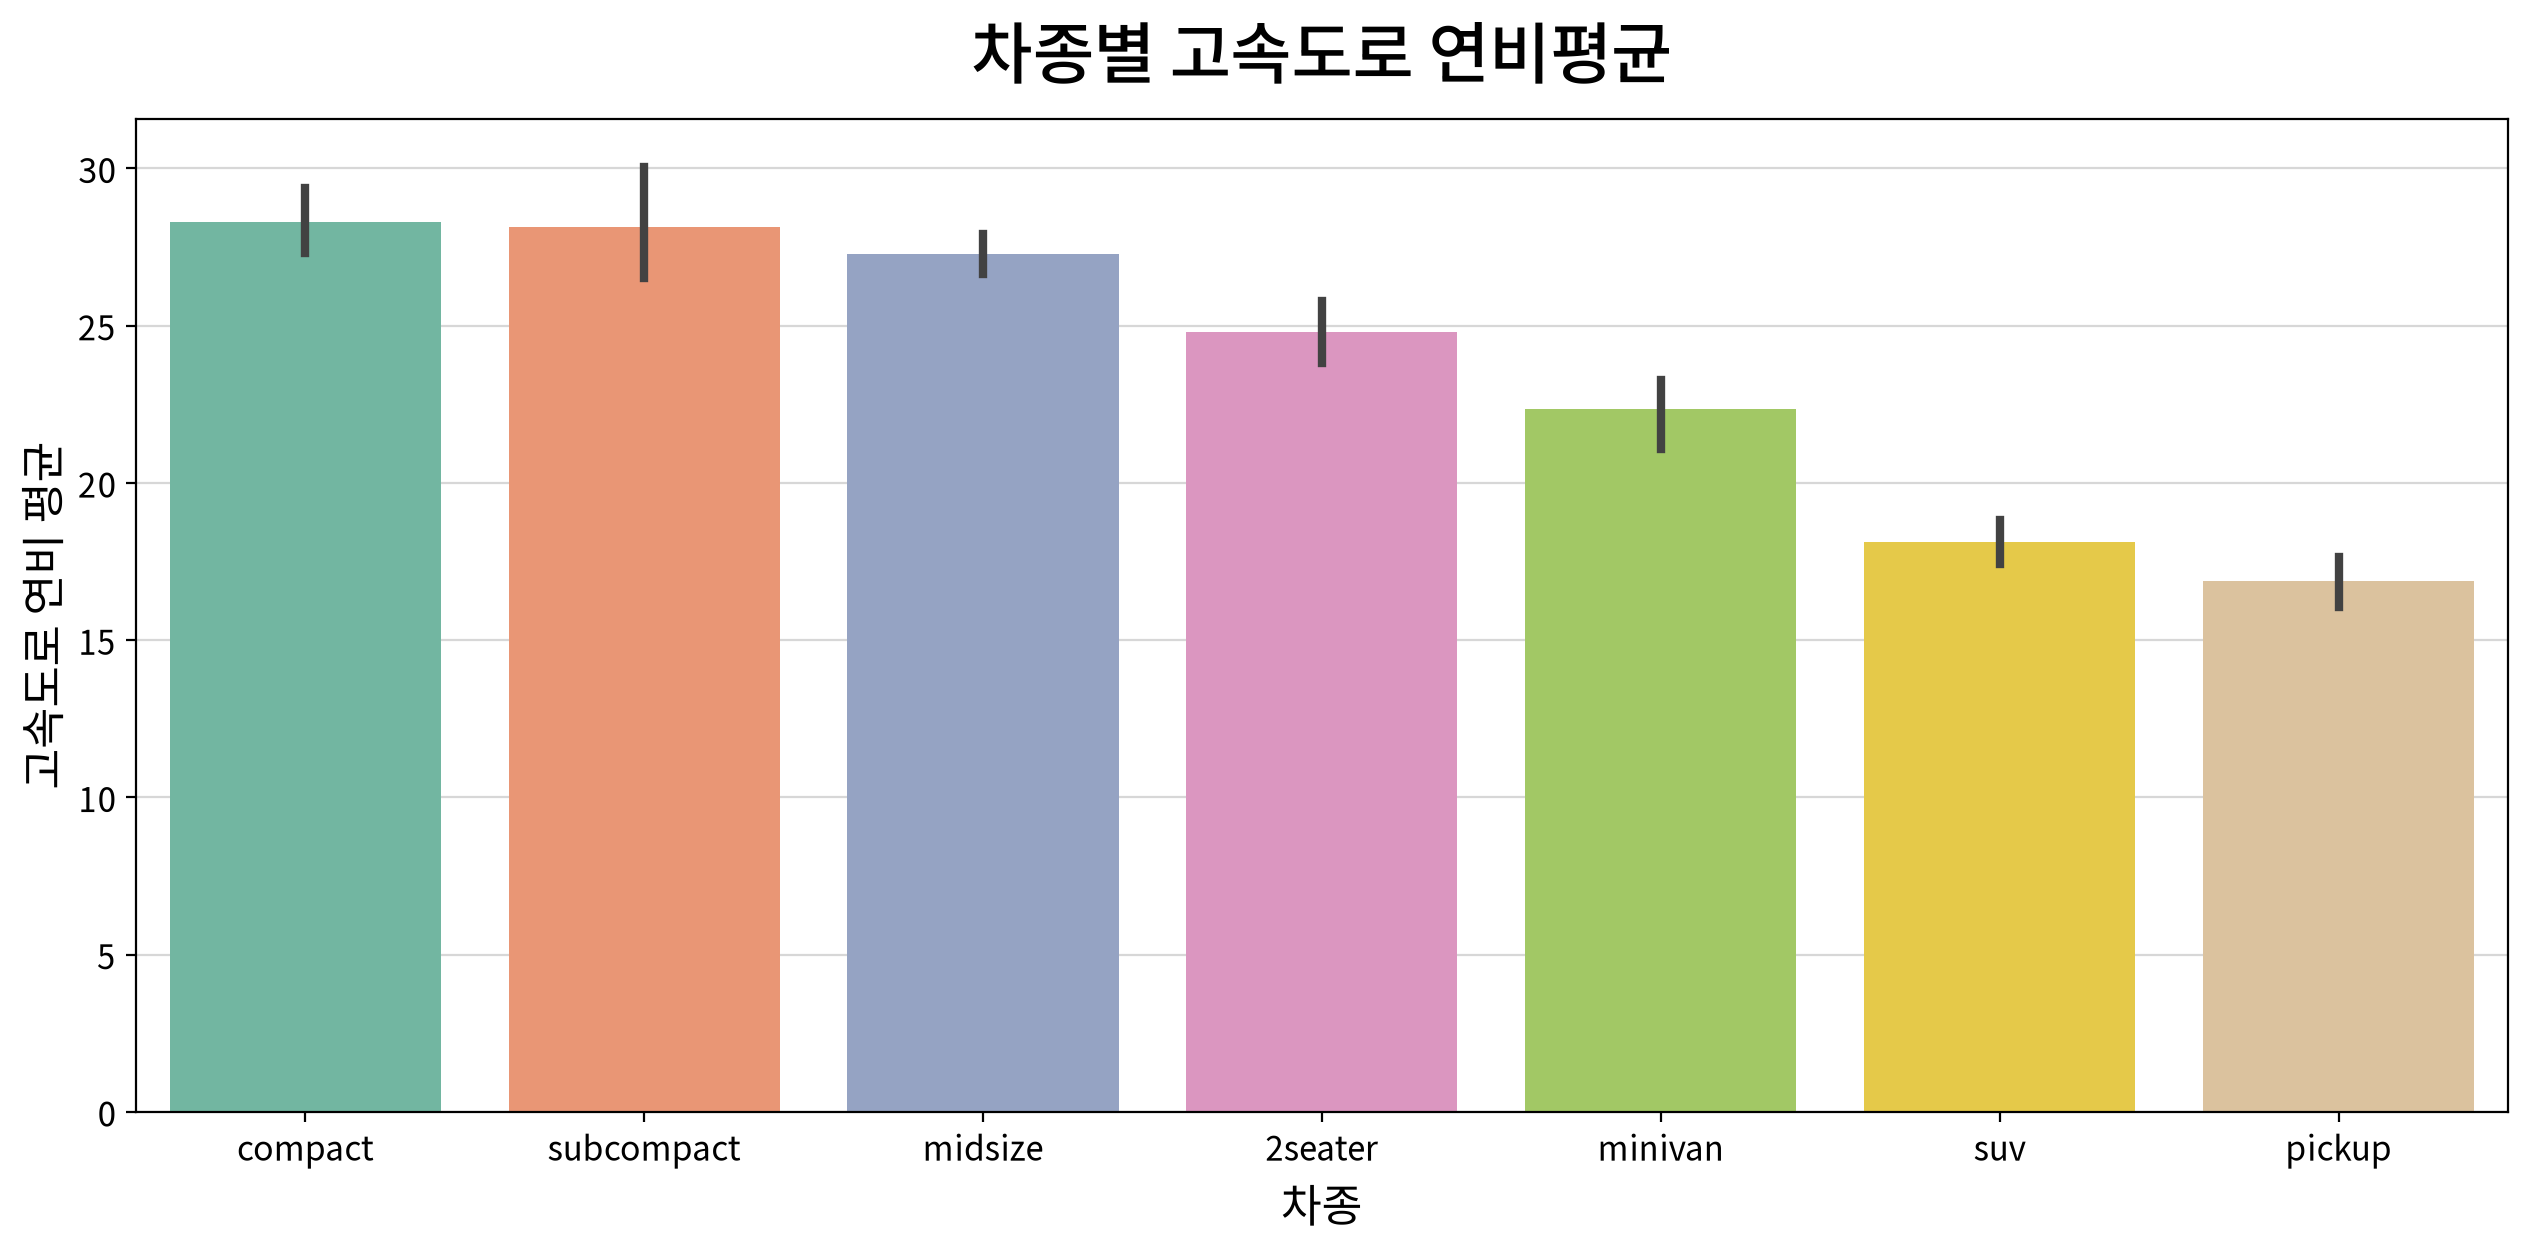

In [12]:
order = df.groupby('class')['hwy'].mean().sort_values(ascending=False).index
my_plot.barplot(df, x='class', y='hwy', estimator=np.mean, title='차종별 고속도로 연비평균', xlabel='차종', ylabel='고속도로 연비 평균', palette='Set2', order=order)

## 정답
#### compact가 근소한 차이로 연비평균이 높음

## 문제 10. 도심 연비(`cty`) 평균이 가장 높은 제조사는?

① volkswagen  ② honda  ③ subaru  ④ hyundai

> 💡 **힌트**: 막대그래프 (제조사별 cty 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


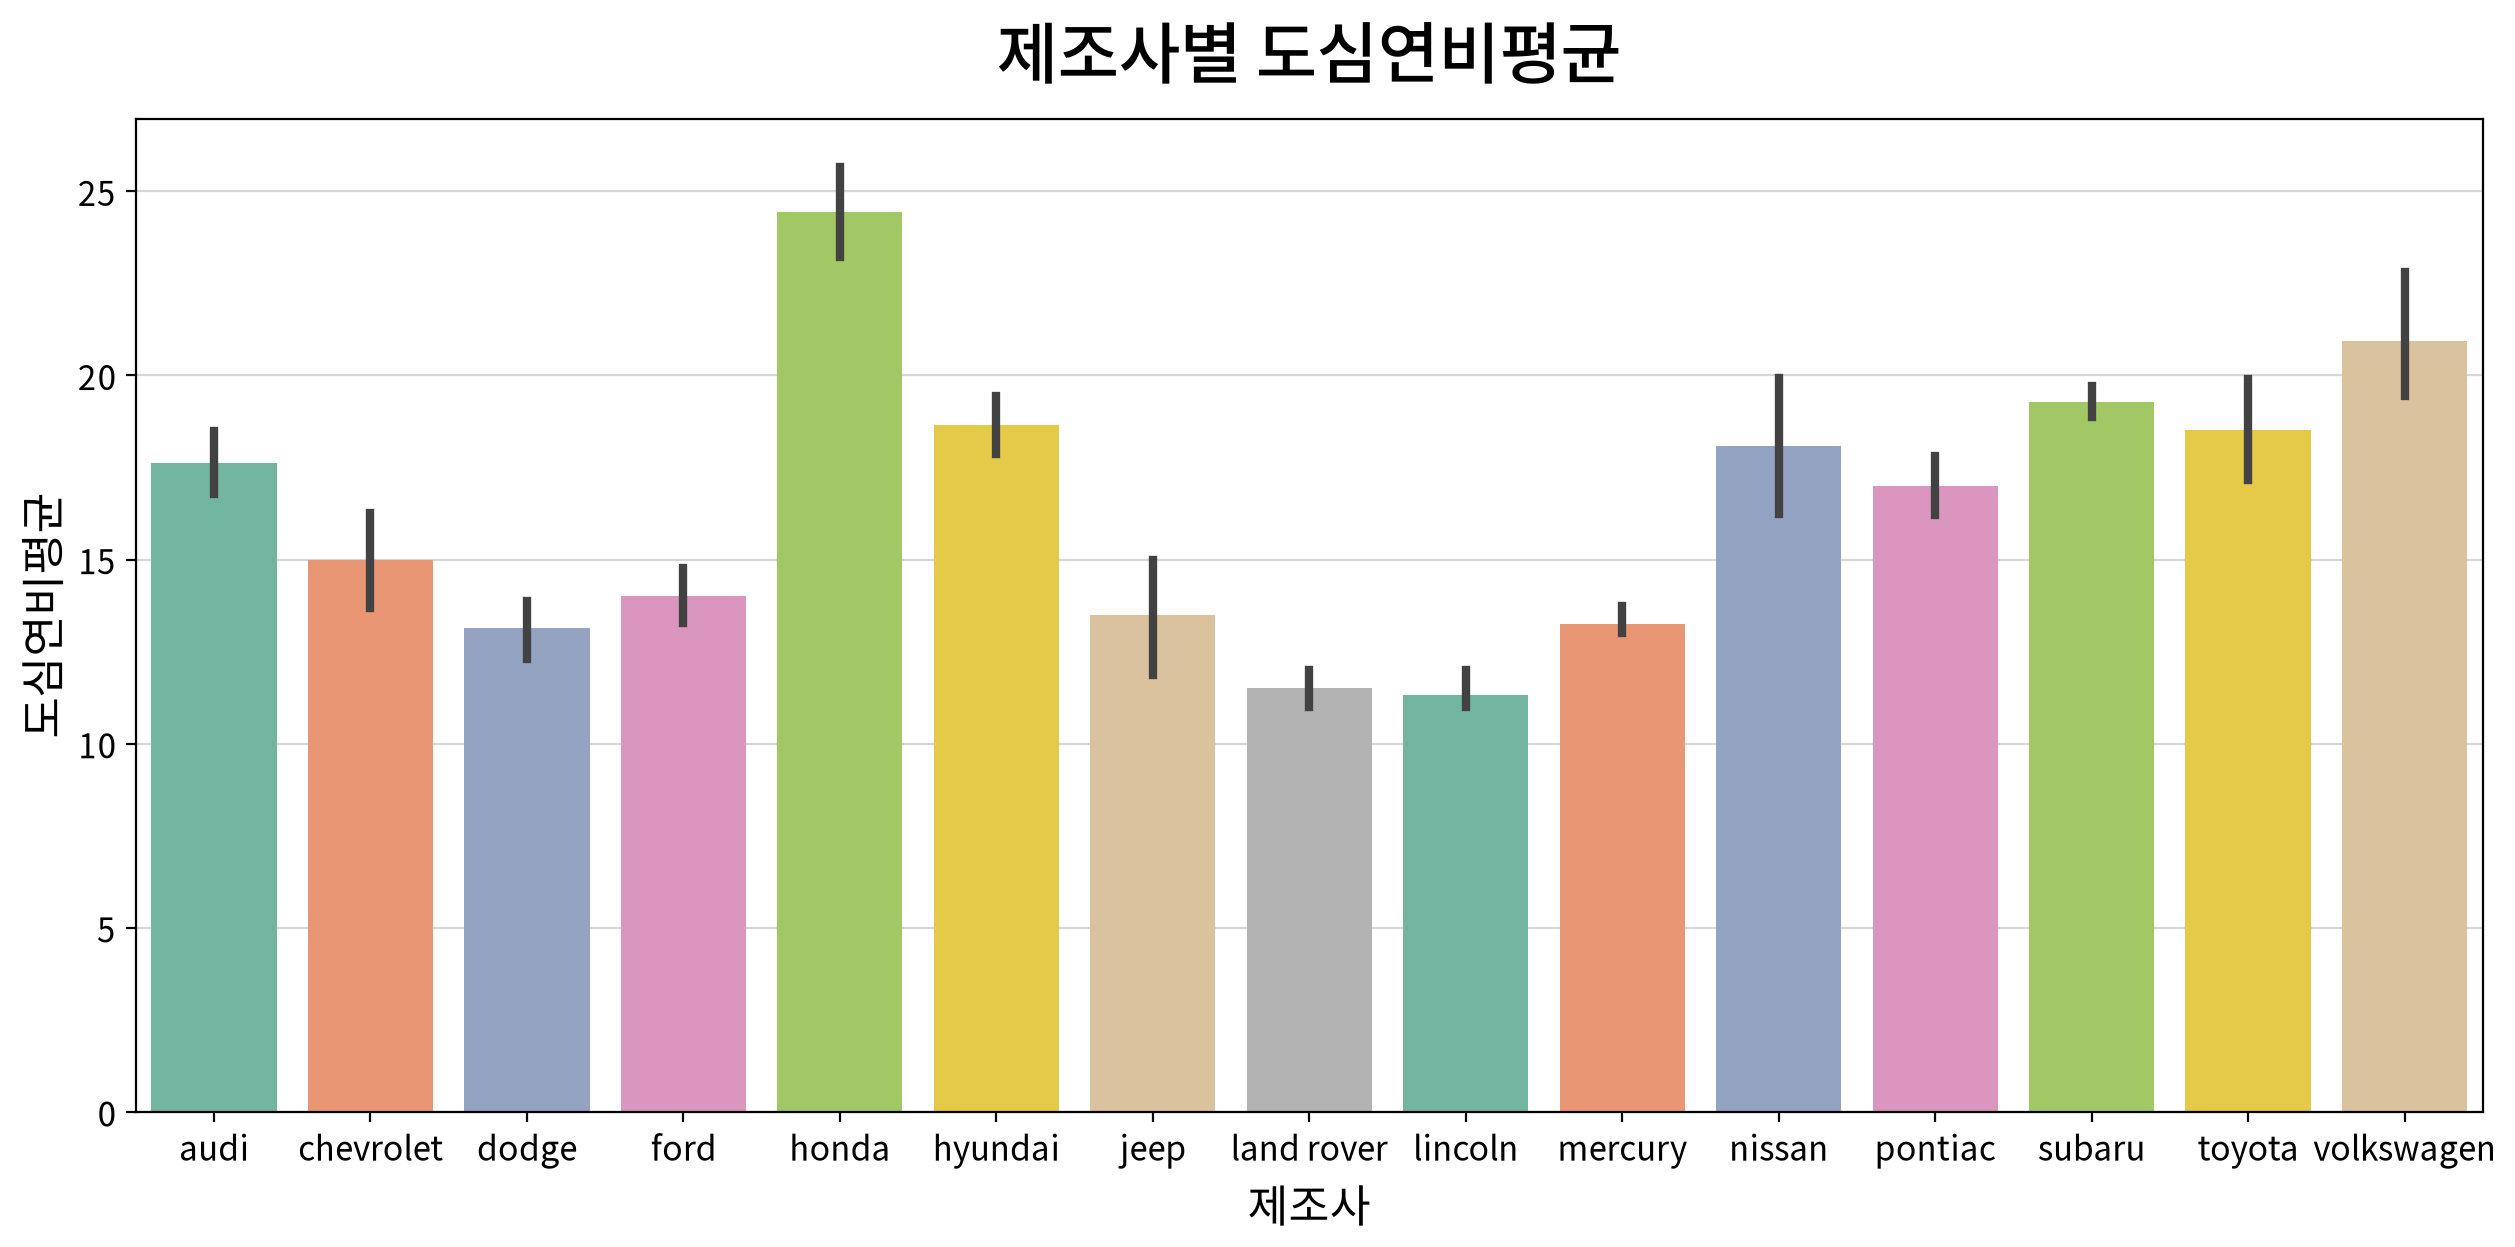

In [13]:
my_plot.barplot(df, x='manufacturer', y='cty', title='제조사별 도심연비평균', estimator=np.mean, xlabel='제조사', ylabel='도심연비평균', palette='Set2')

## 정답
#### honda 제조사가 도심연비평균이 가장 좋음

## 문제 11. 고속도로 연비(`hwy`) 평균이 가장 낮은 제조사는?

① dodge  ② lincoln  ③ land rover  ④ jeep

> 💡 **힌트**: 막대그래프 (제조사별 hwy 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


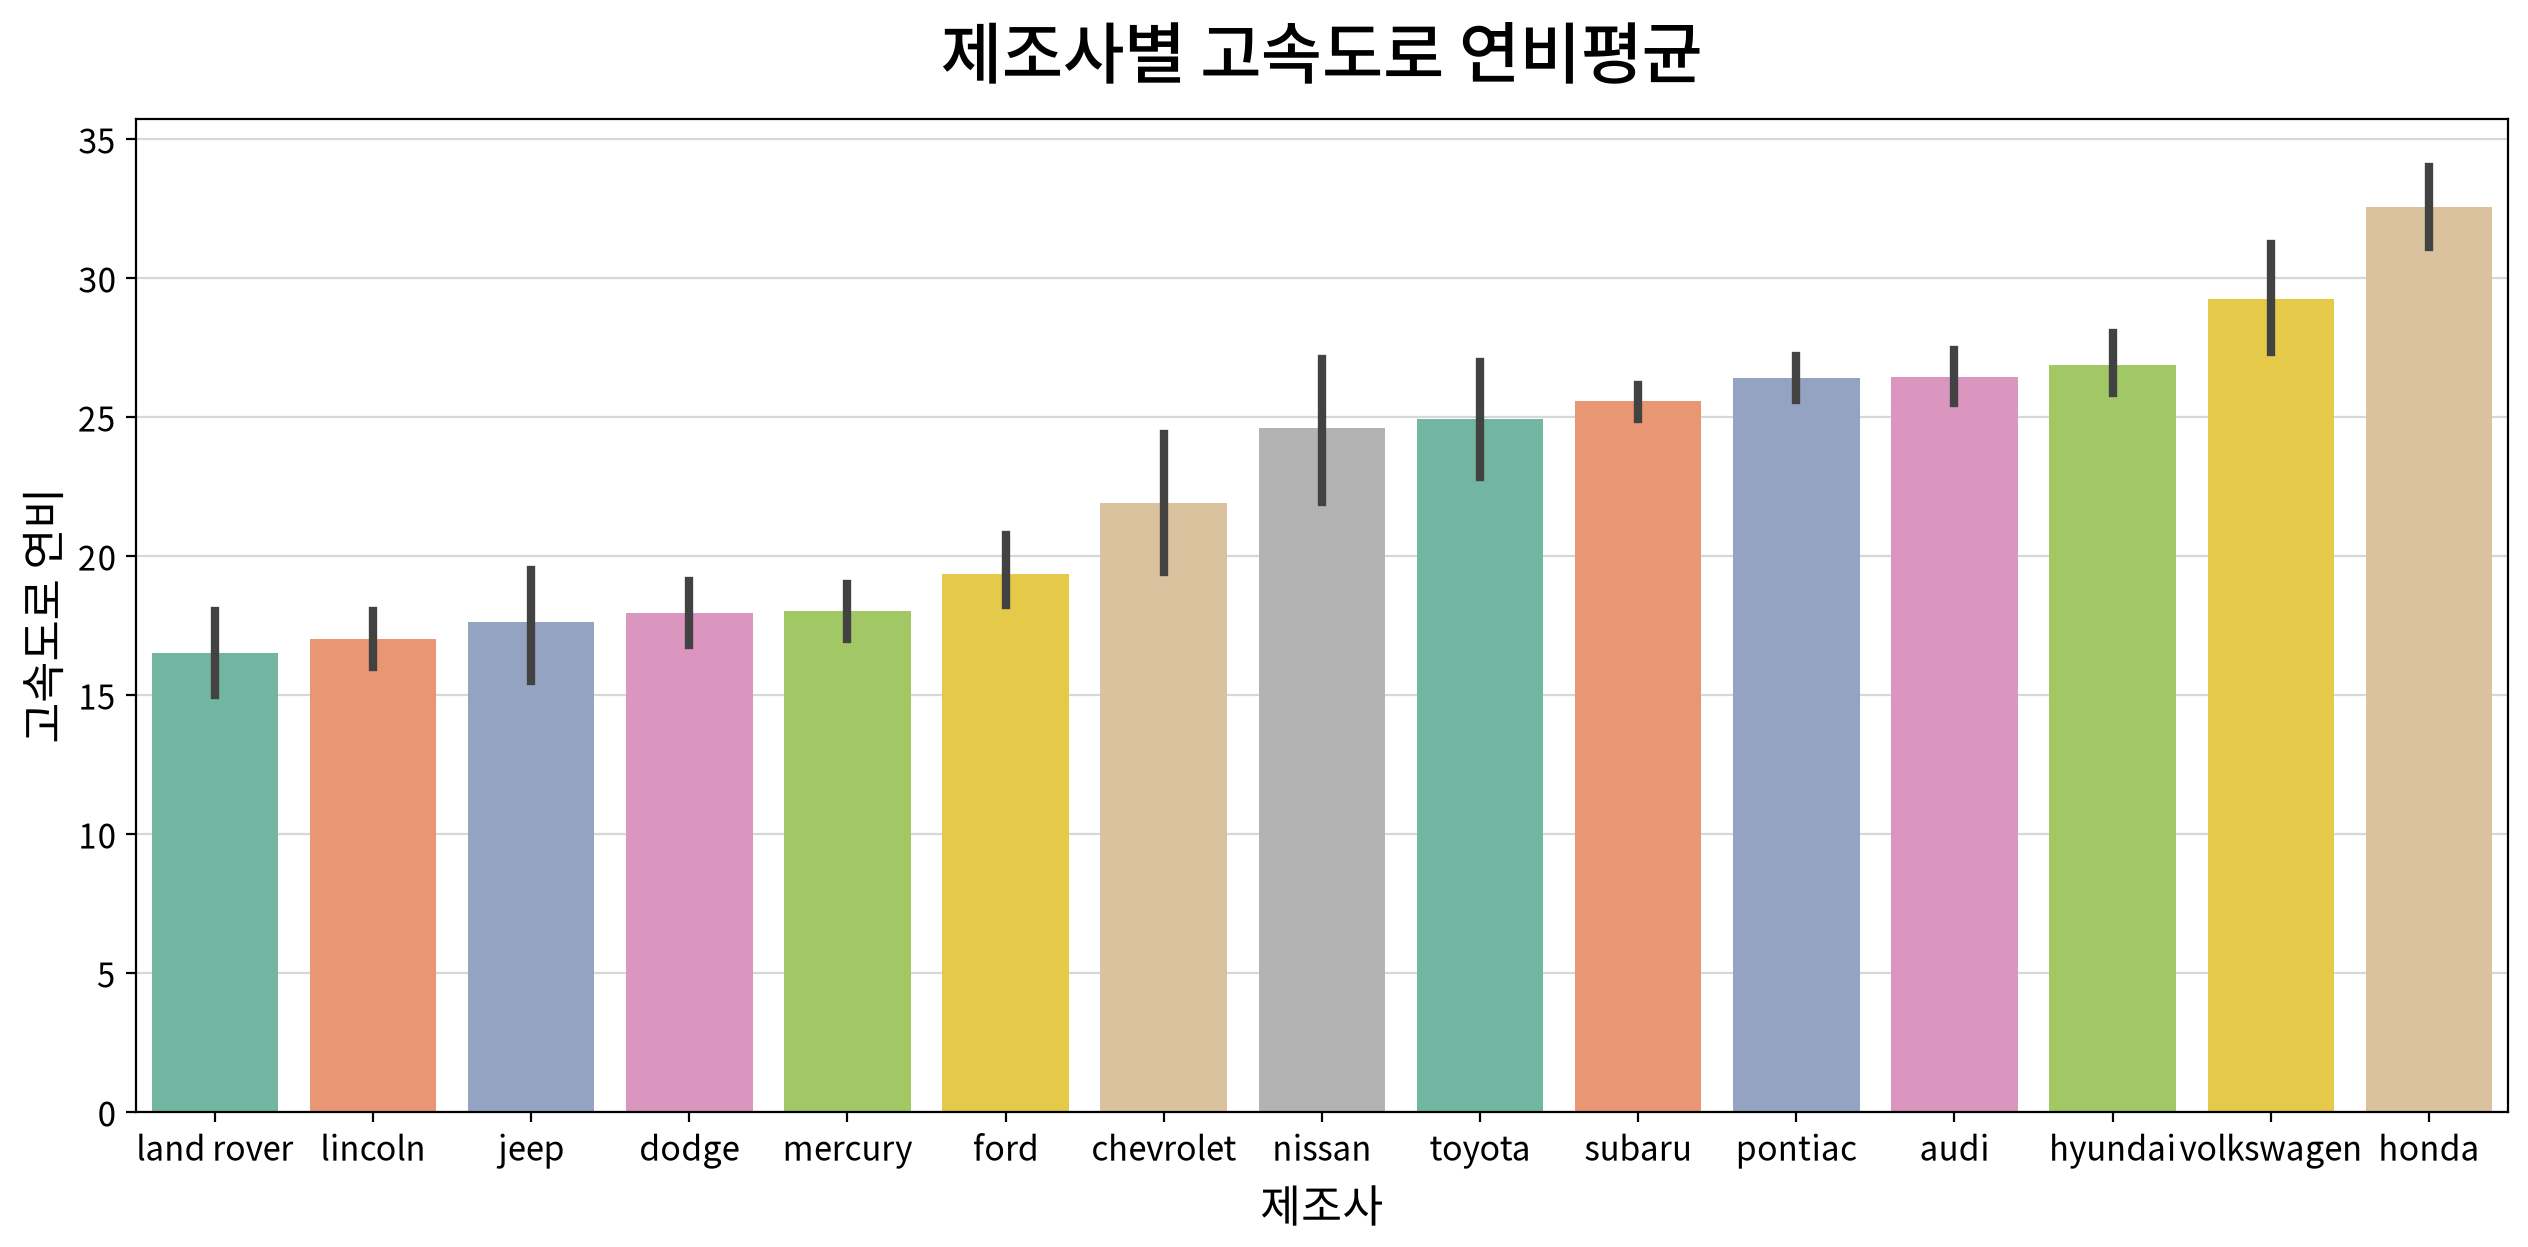

In [14]:
order = df.groupby('manufacturer')['hwy'].mean().sort_values(ascending=True).index
my_plot.barplot(df, x='manufacturer', y='hwy', title='제조사별 고속도로 연비평균', xlabel='제조사', ylabel='고속도로 연비', palette='Set2', order=order)

## 정답
#### land rover 제조사가 고속도로에서 평균 연비가 제일 안좋다

## 문제 12. 변속기 종류(자동 vs 수동)에 따른 연비 비교로 옳은 것은?

① 자동이 수동보다 연비가 높다  ② 수동이 자동보다 연비가 높다  ③ 차이가 없다  ④ 도심은 자동, 고속도로는 수동이 높다

> 💡 **힌트**: 막대그래프 (`trans`를 auto/manual로 묶은 뒤 cty·hwy 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


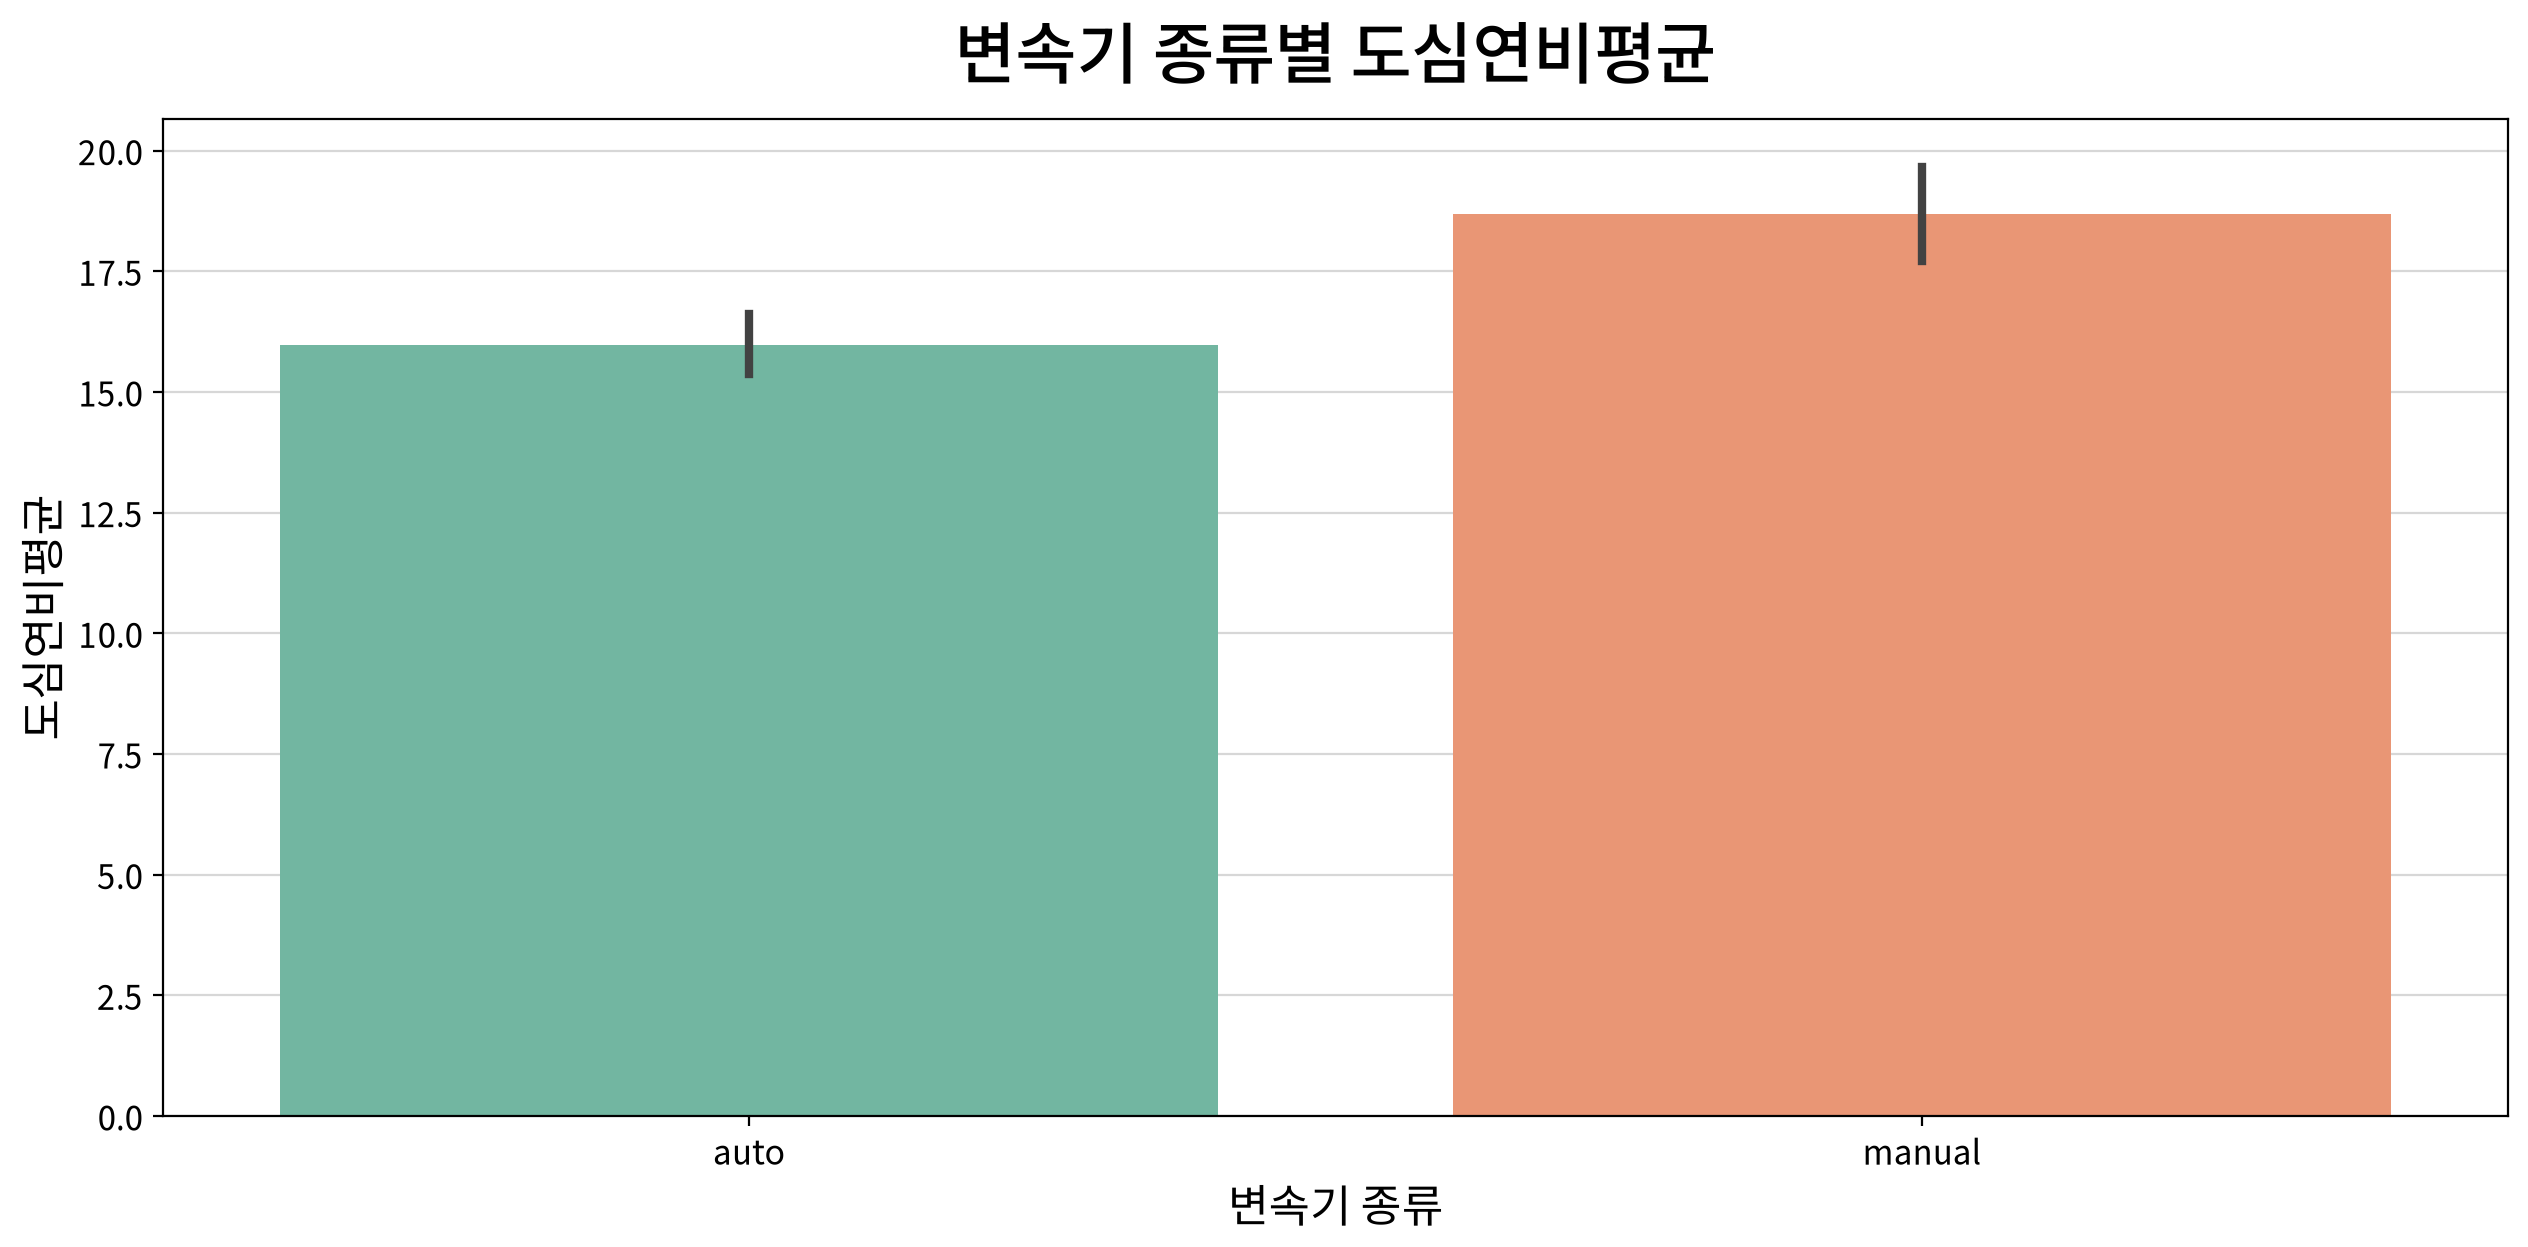

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


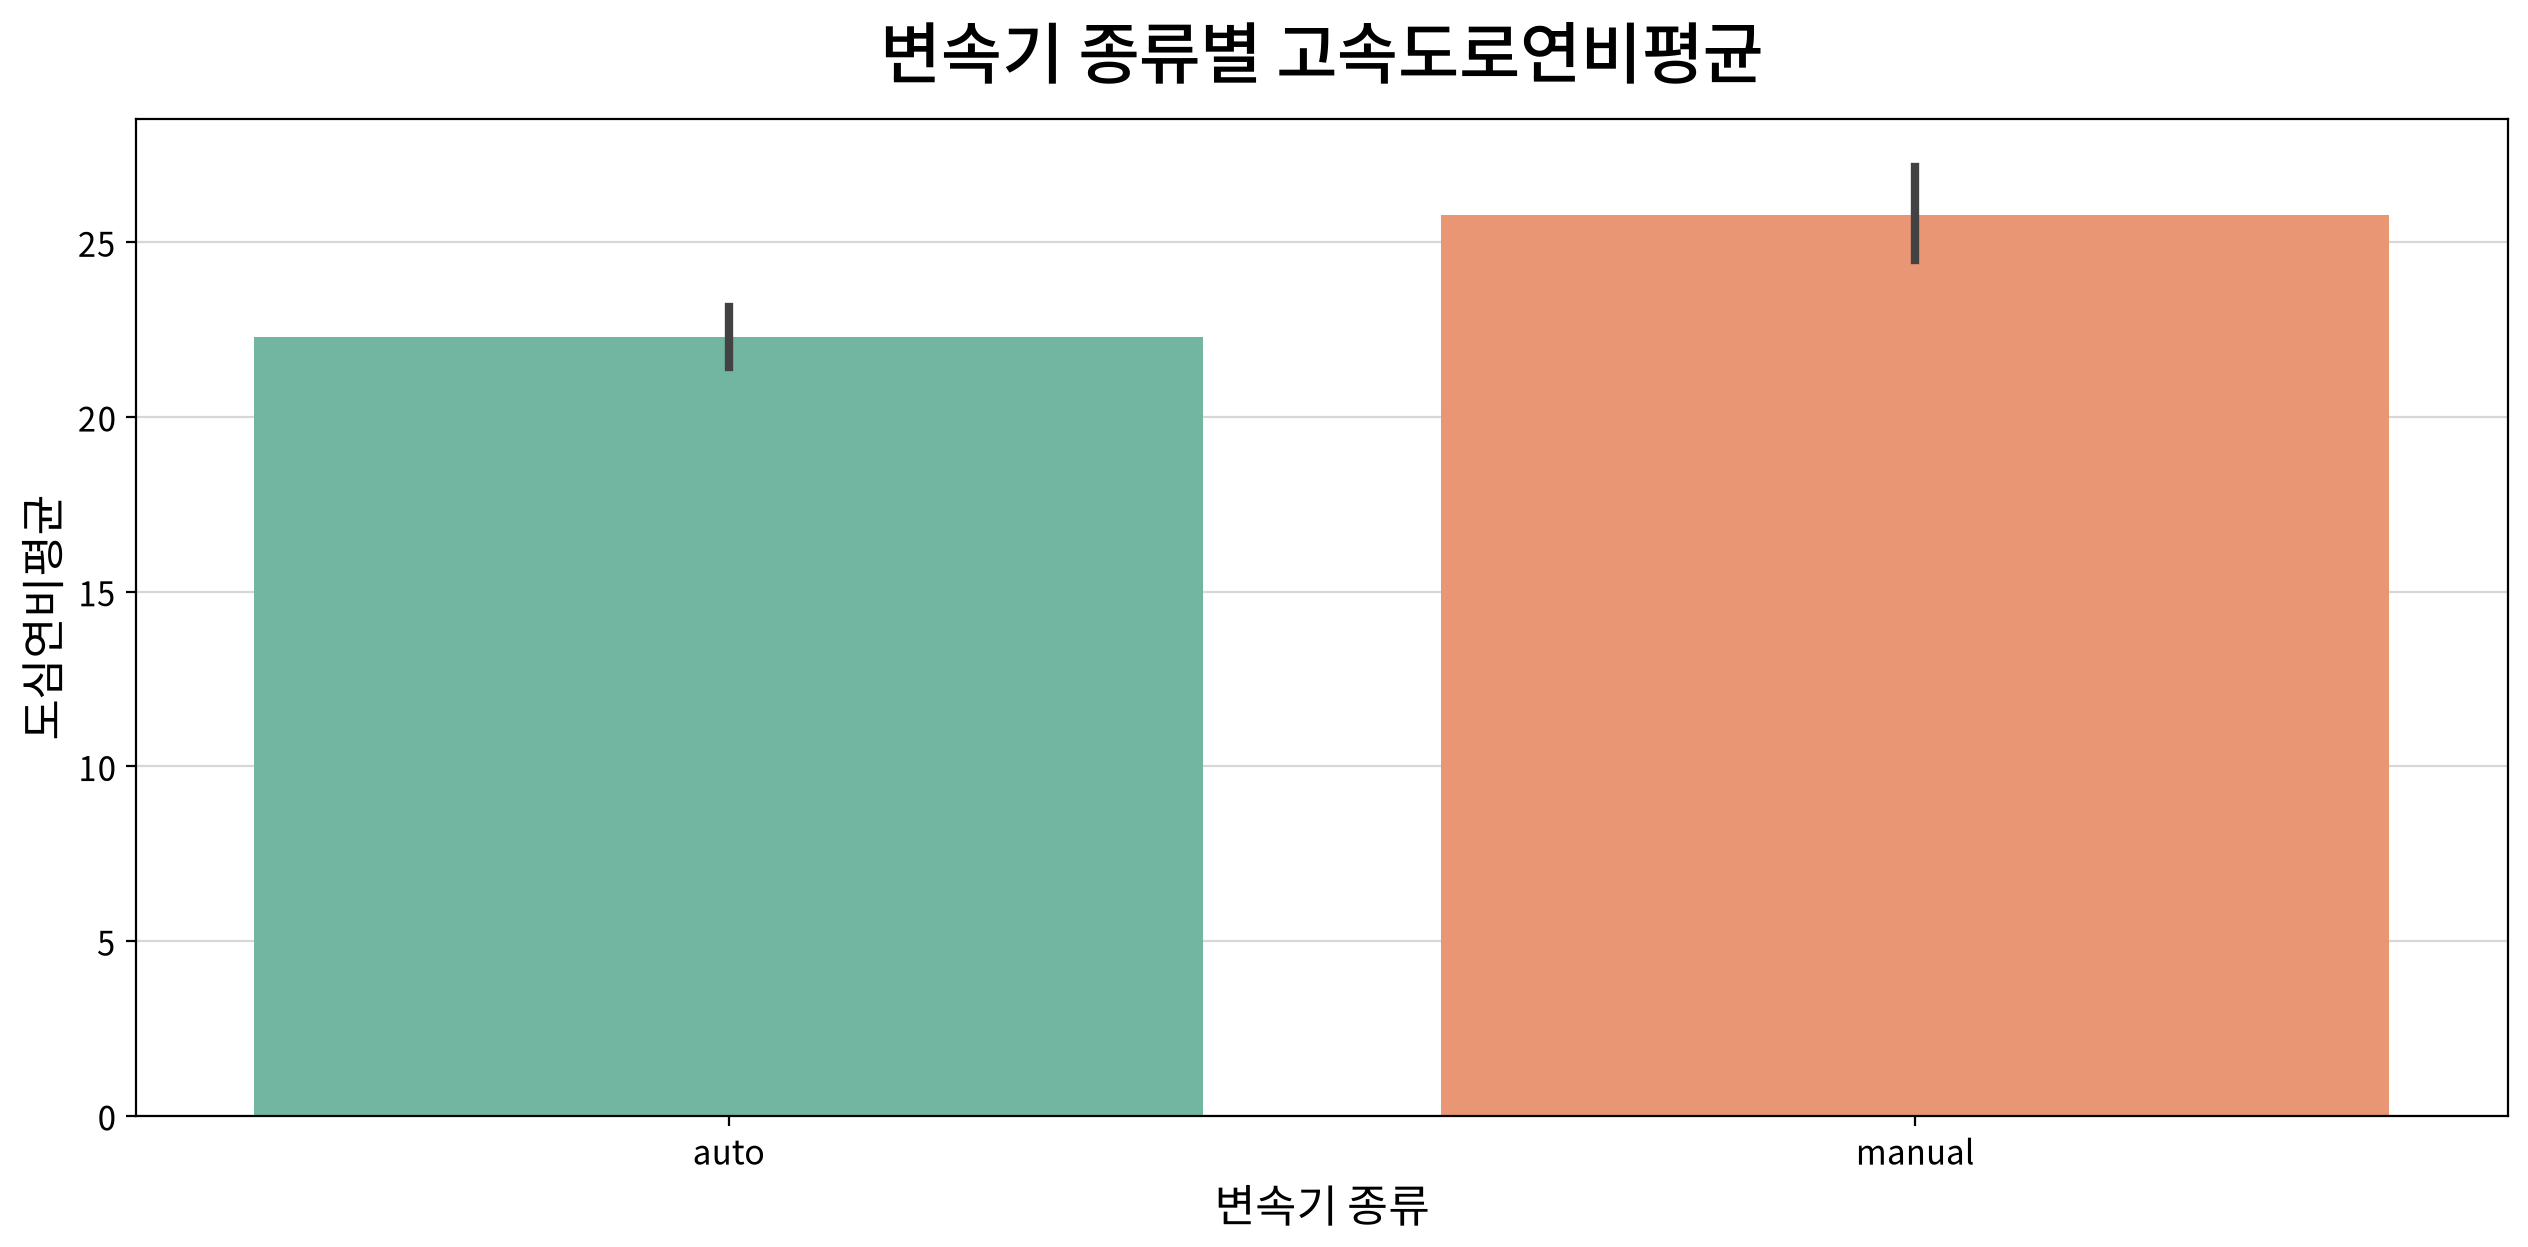

In [15]:
df.loc[df['trans'].str.contains('auto'), 'trans'] = 'auto'
df.loc[df['trans'].str.contains('manual'), 'trans'] = 'manual'
df.head()
my_plot.barplot(df,x='trans', y='cty', title='변속기 종류별 도심연비평균', estimator=np.mean, xlabel='변속기 종류', ylabel='도심연비평균', palette='Set2')
my_plot.barplot(df,x='trans', y='hwy', title='변속기 종류별 고속도로연비평균', estimator=np.mean, xlabel='변속기 종류', ylabel='도심연비평균', palette='Set2')

## 정답
#### 도심,고속도로 둘다 평균연비가 수동이 더 좋다.

## 문제 13. 가장 많이 사용된 연료(`fl`) 종류는?

① p (프리미엄)  ② r (레귤러)  ③ e (에탄올)  ④ d (디젤)

> 💡 **힌트**: 막대그래프 또는 원그래프 (연료별 빈도)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


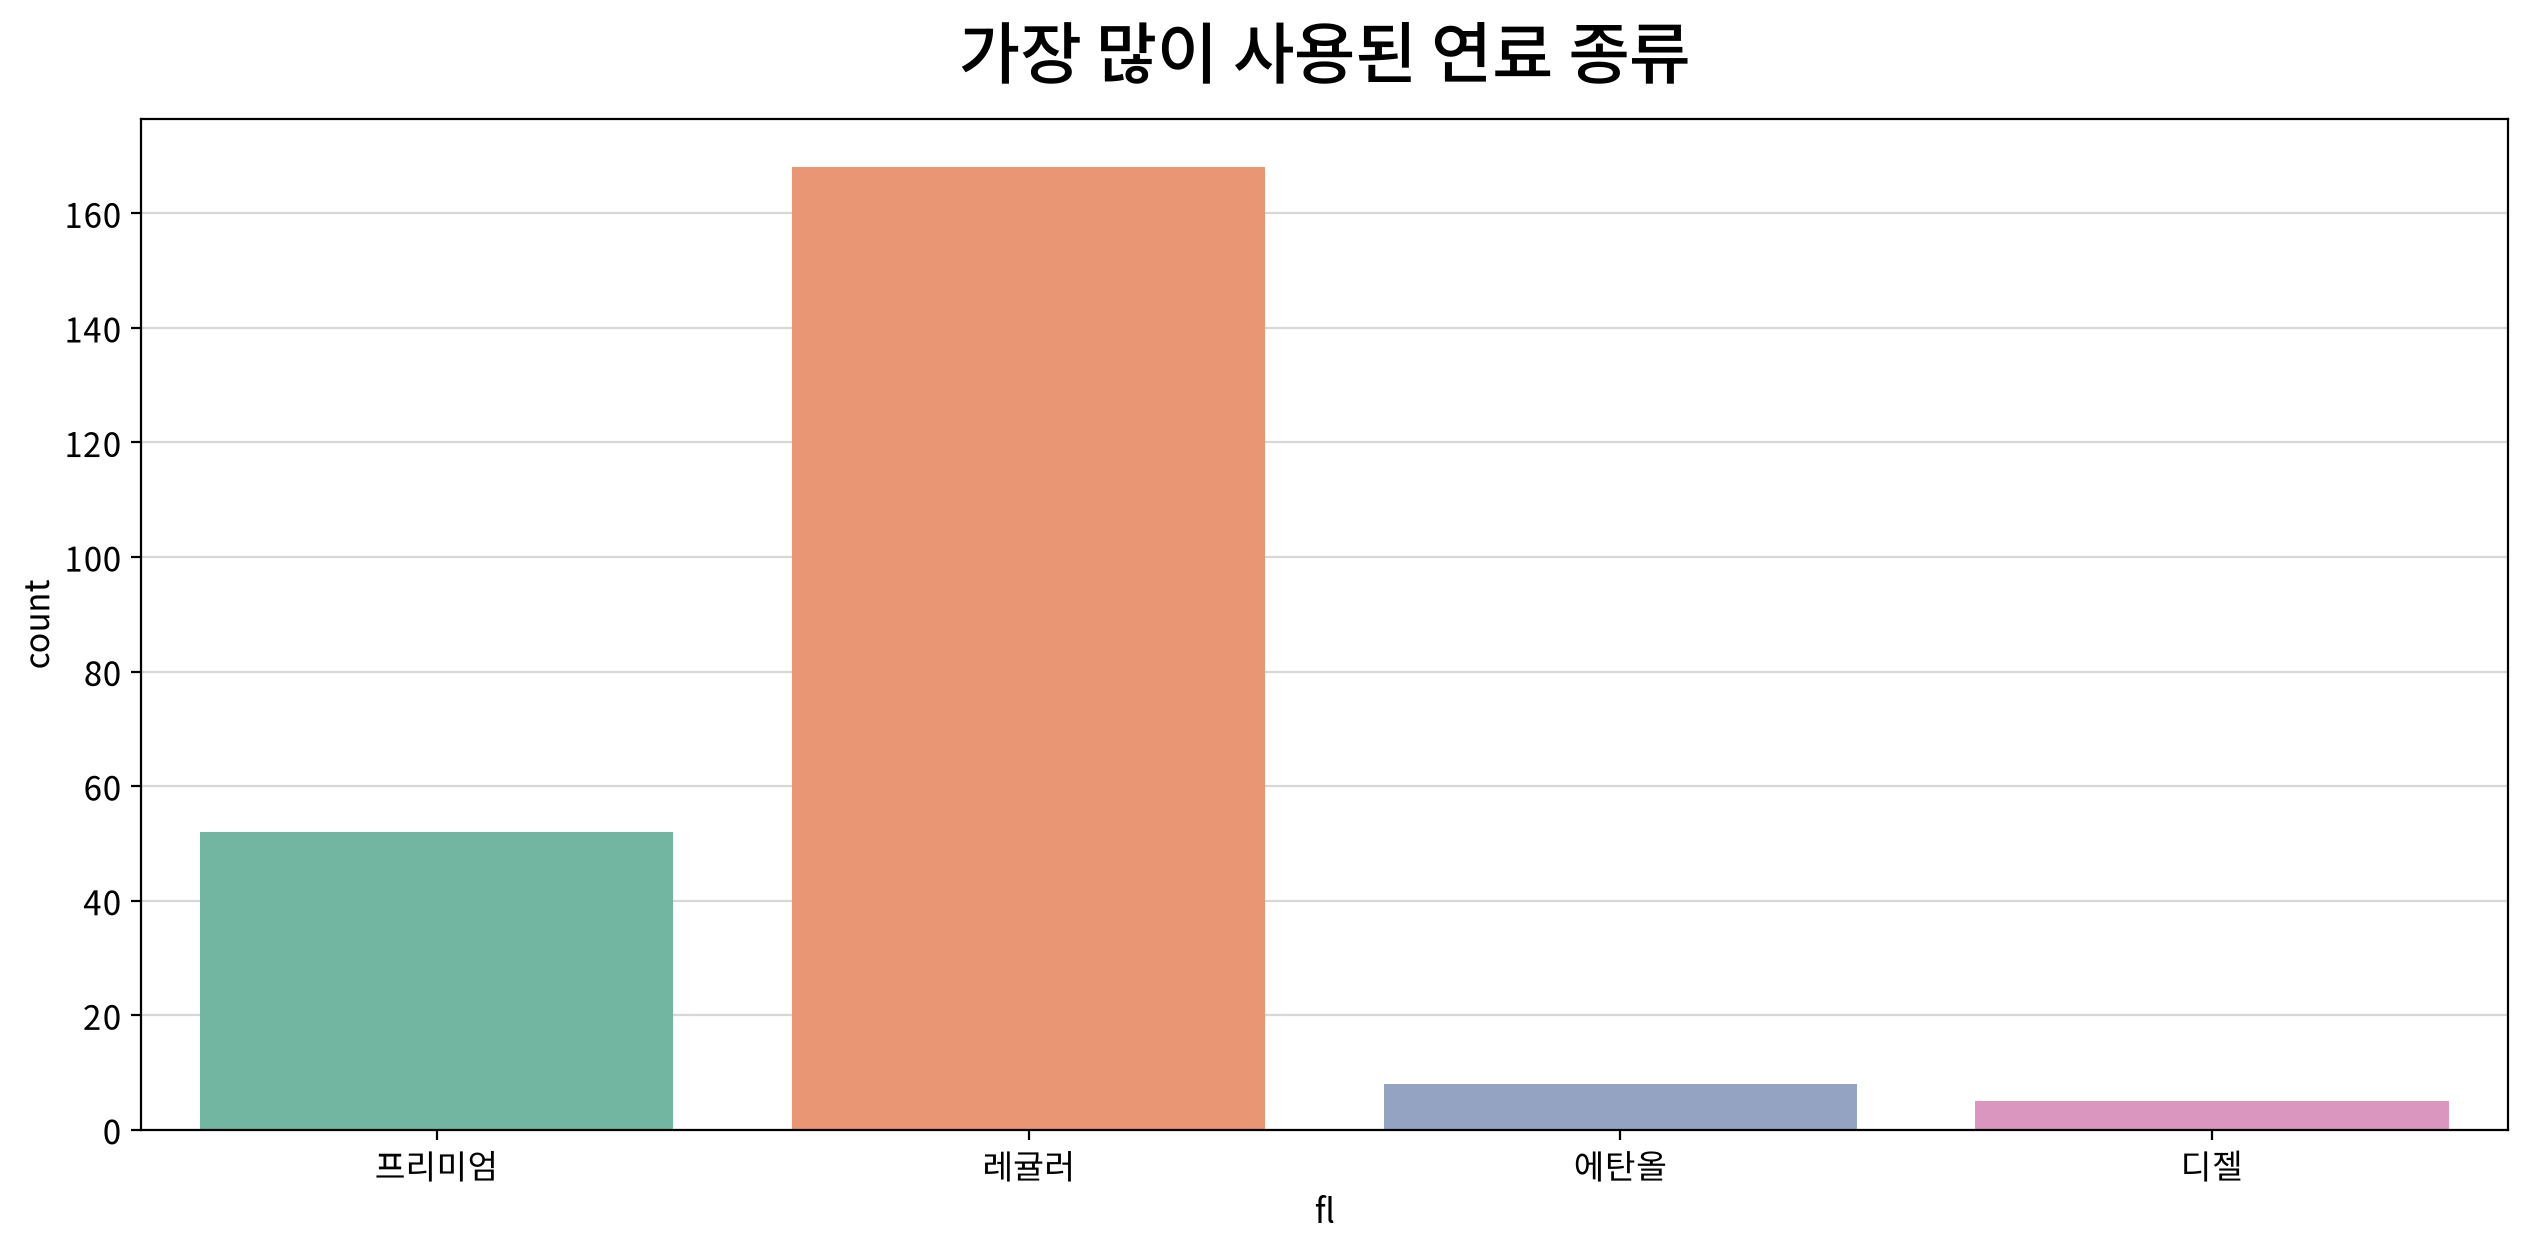

In [16]:
df['fl'] = df['fl'].map({"p": "프리미엄", "r": "레귤러", "e": "에탄올", "d": "디젤"})
my_plot.countplot(df ,x='fl', title='가장 많이 사용된 연료 종류', palette='Set2')

## 정답
#### 레귤러 연로가 제일 많이 사용됨

## 문제 14. 1999년과 2008년의 평균 고속도로 연비(`hwy`)를 비교하면?

① 2008년이 크게 향상되었다  ② 1999년이 더 높다  ③ 거의 차이가 없다  ④ 2008년이 절반 수준이다

> 💡 **힌트**: 막대그래프 (연식별 hwy 평균)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:215: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.barplot(data=data, x=x, y=y, hue=hue, estimator=estimator, order=order, palette=palette, ax=ax)


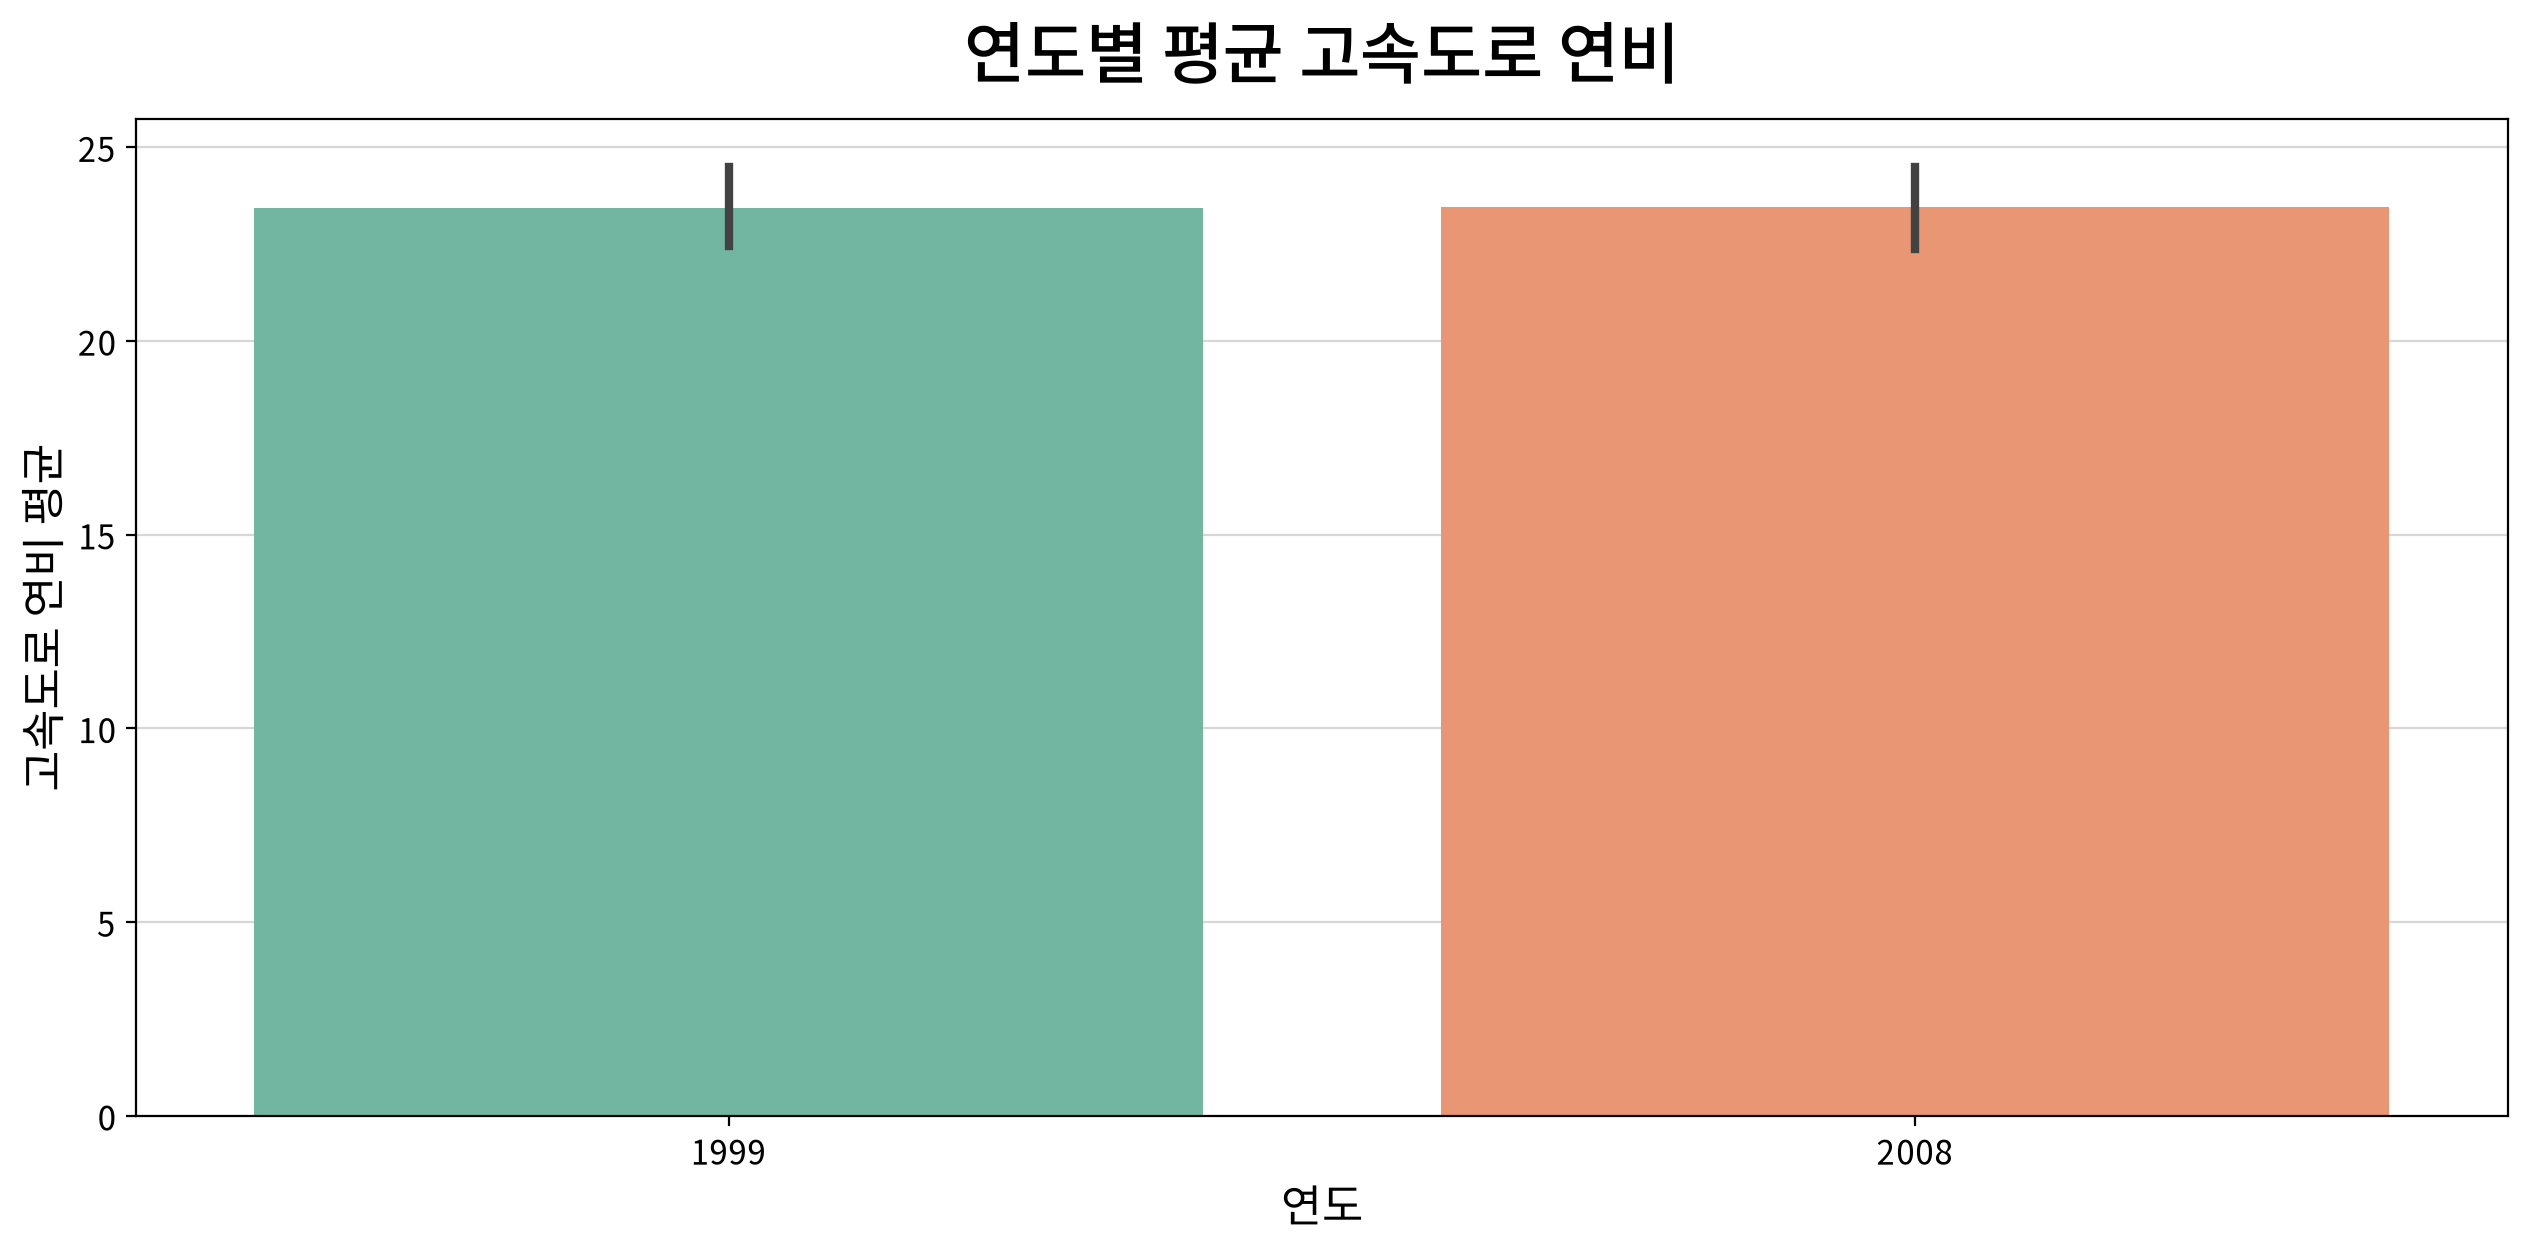

In [17]:
my_plot.barplot(df, x='year', y='hwy', estimator=np.mean, title='연도별 평균 고속도로 연비', xlabel='연도', ylabel='고속도로 연비 평균', palette='Set2')

## 정답
#### 연비효율 차이가 거의 없다

## 문제 15. SUV 차종에는 존재하지 않는 구동방식은?

① 4륜구동  ② 후륜구동  ③ 전륜구동  ④ 모두 존재한다

> 💡 **힌트**: 막대그래프 (차종 SUV로 필터 후 구동방식별 빈도) 또는 교차표 시각화

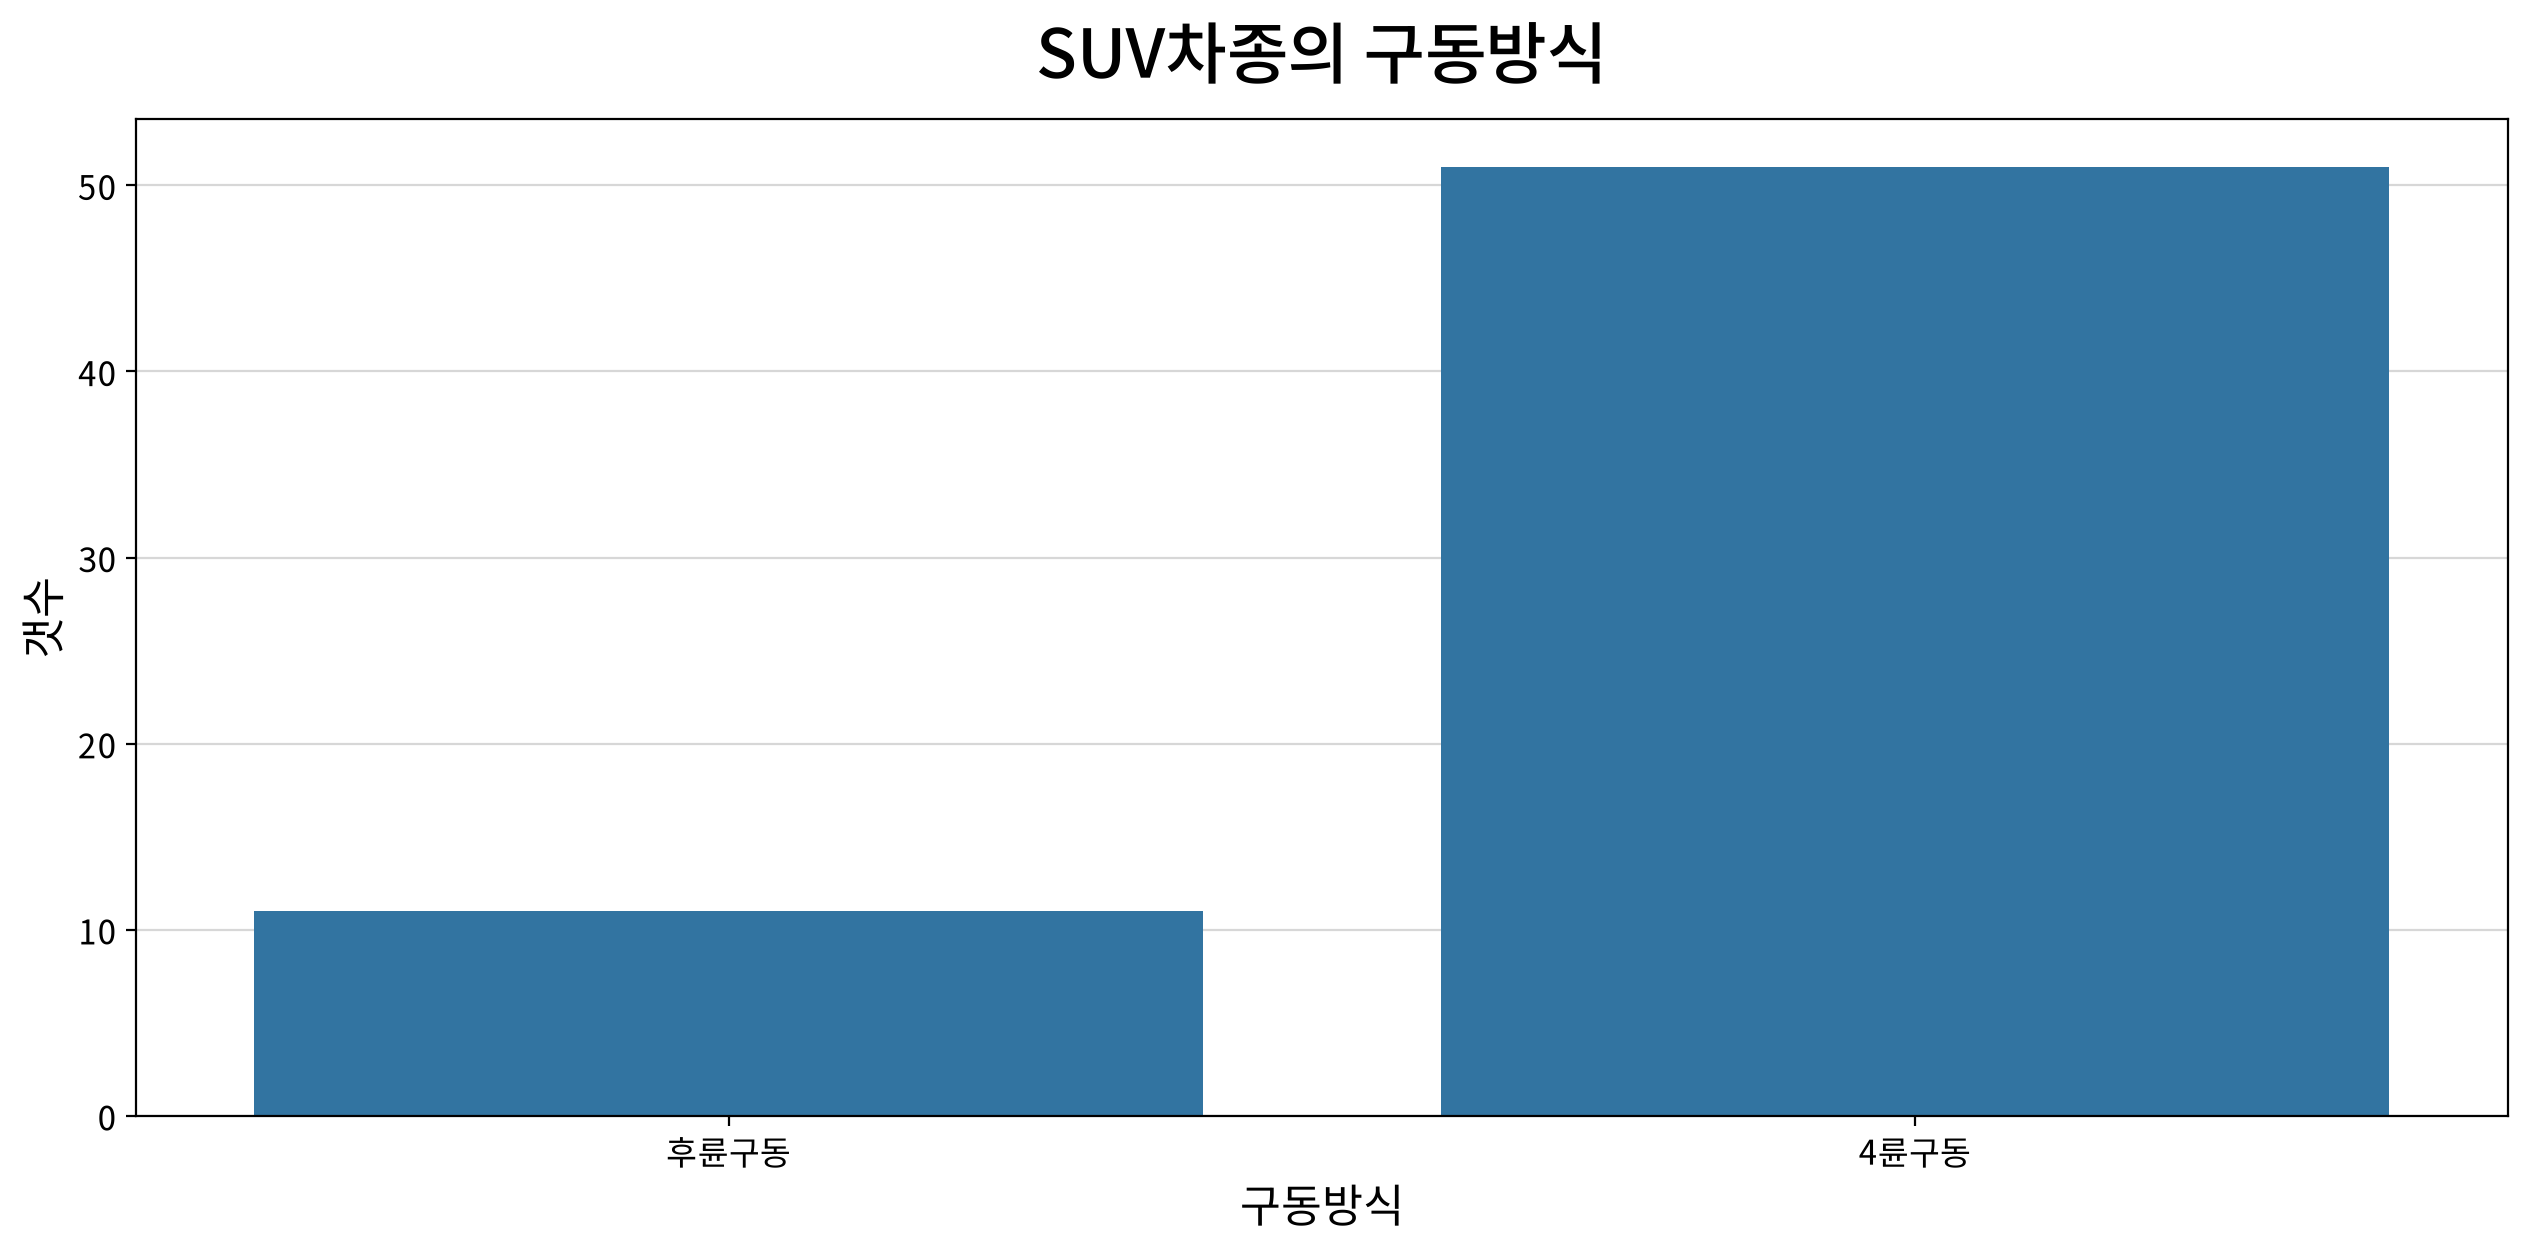

In [33]:
df2 = df[df['class'] == 'suv']
my_plot.countplot(df2, x='drv', title='SUV차종의 구동방식', xlabel='구동방식', ylabel='갯수')

## 정답
#### 전륜구동이 없다.

## 문제 16. 픽업(pickup) 차종의 구동방식은?

① 모두 4륜구동  ② 모두 전륜구동  ③ 4륜·후륜 혼합  ④ 전륜·4륜 혼합

> 💡 **힌트**: 막대그래프 (차종 pickup으로 필터 후 구동방식별 빈도)

c:\Users\ITWILL\Desktop\주영아강사님\연습\helper\my_plot.py:235: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sb.countplot(data=data, x=x, y=y, hue=hue, order=order, palette=palette, ax=ax)


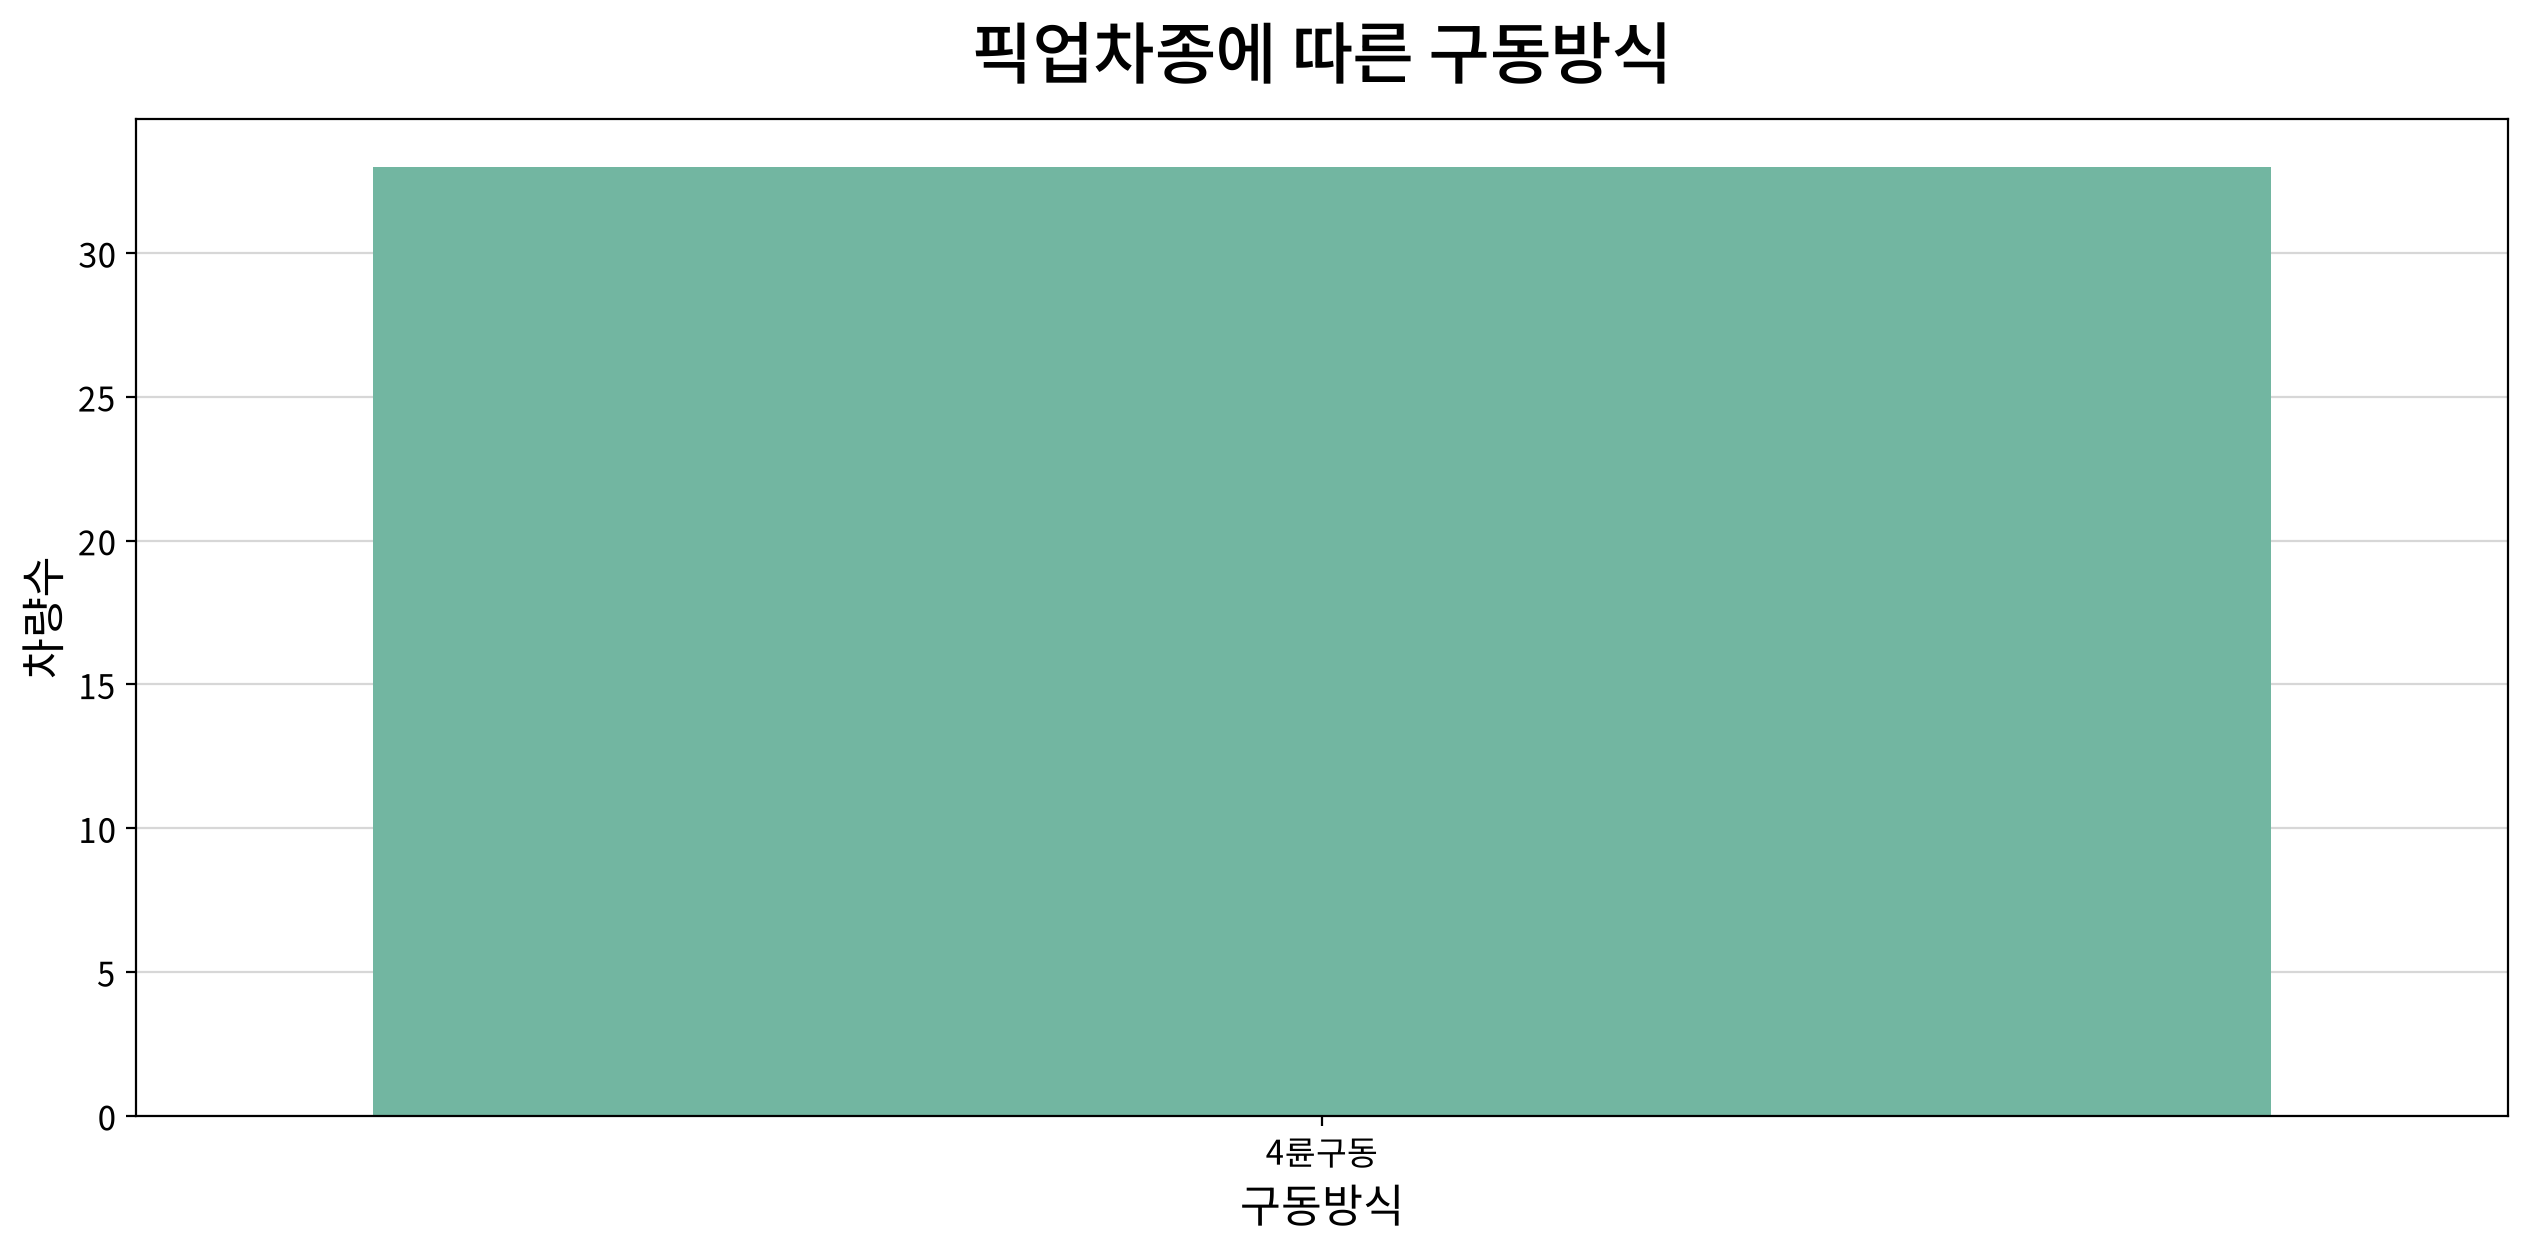

In [35]:
df3 = df[df['class'] == 'pickup']
my_plot.countplot(df3, x='drv', title='픽업차종에 따른 구동방식', xlabel='구동방식', ylabel='차량수', palette='Set2')

## 정답
#### 모두 4륜구동

## 문제 17. 평균연비 `(cty + hwy) / 2`가 전체 평균보다 높은(합격, Pass) 차량의 비율에 가장 가까운 값은?

① 약 25%  ② 약 47%  ③ 약 53%  ④ 약 75%

> 💡 **힌트**: 원그래프 (Pass/Fail 비율)

In [58]:
df3 = df.copy()
df3['평균연비'] = (df3['cty'] + df3['hwy']) / 2
df3['합격여부'] = np.where(df3['평균연비'] >= df3['평균연비'].mean(), '합격', '불합격')
df3
df3.head()
df4 = df3['합격여부'].value_counts()
df5 = df4.sort_index()
df6 = DataFrame(df5)
df6

,count
합격여부,
불합격,111
합격,123


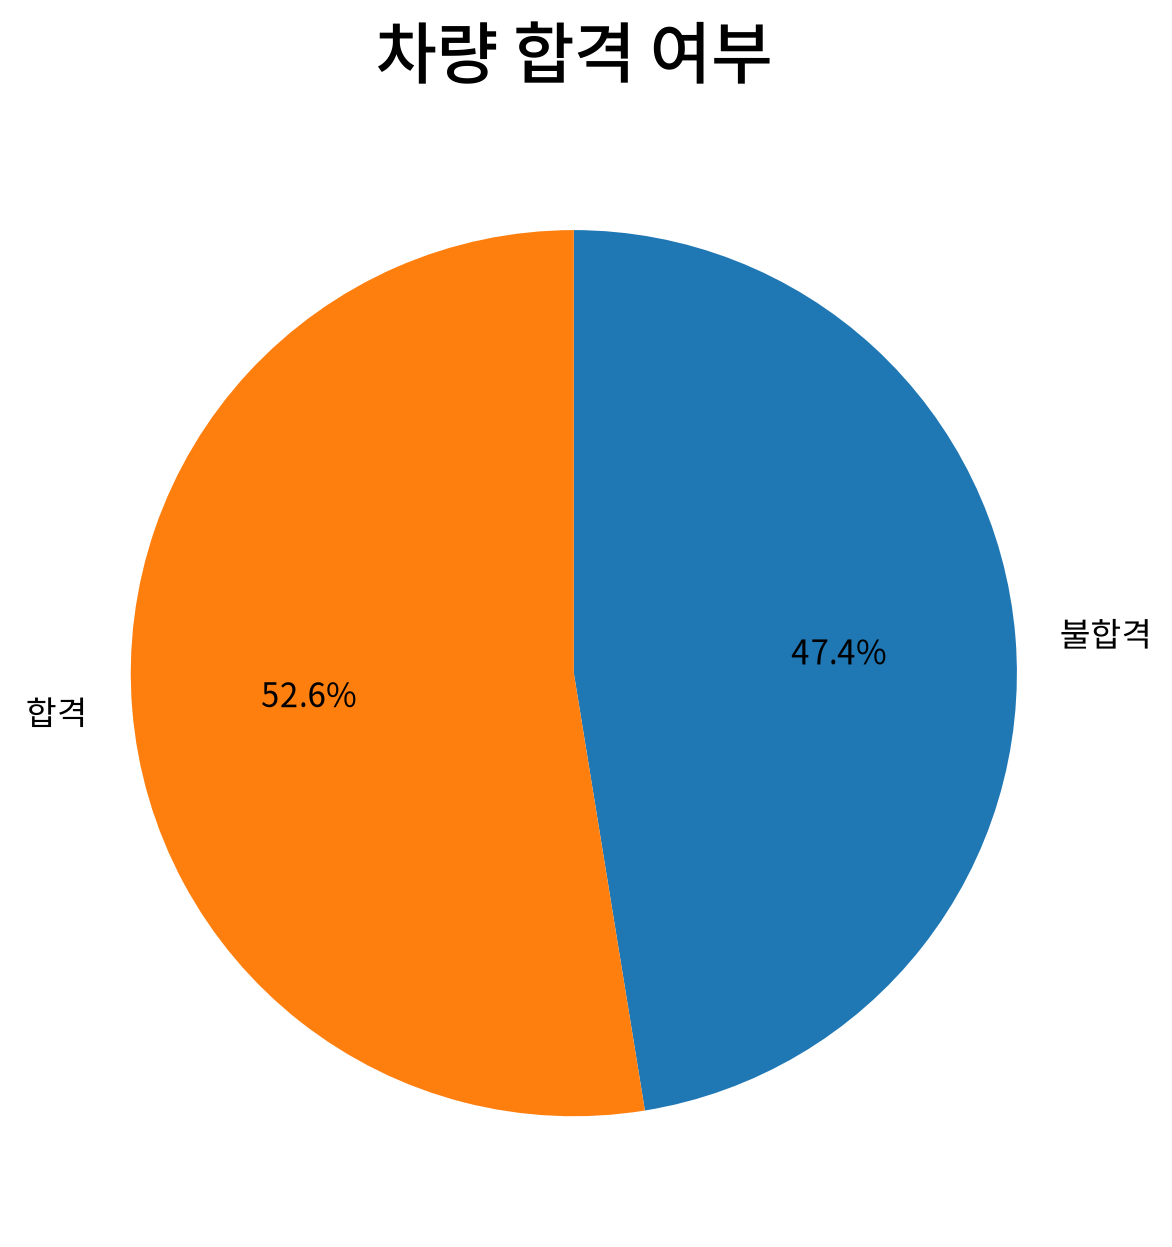

In [67]:
my_plot.pieplot(x= df6['count'], title='차량 합격 여부', labels=df5.index)

## 정답
#### 약 53%

## 문제 18. 배기량(`displ`) 분포의 중앙값(median)에 가장 가까운 값은?

① 2.4  ② 3.3  ③ 3.5  ④ 4.6

> 💡 **힌트**: 히스토그램 또는 박스플롯 (displ 분포)

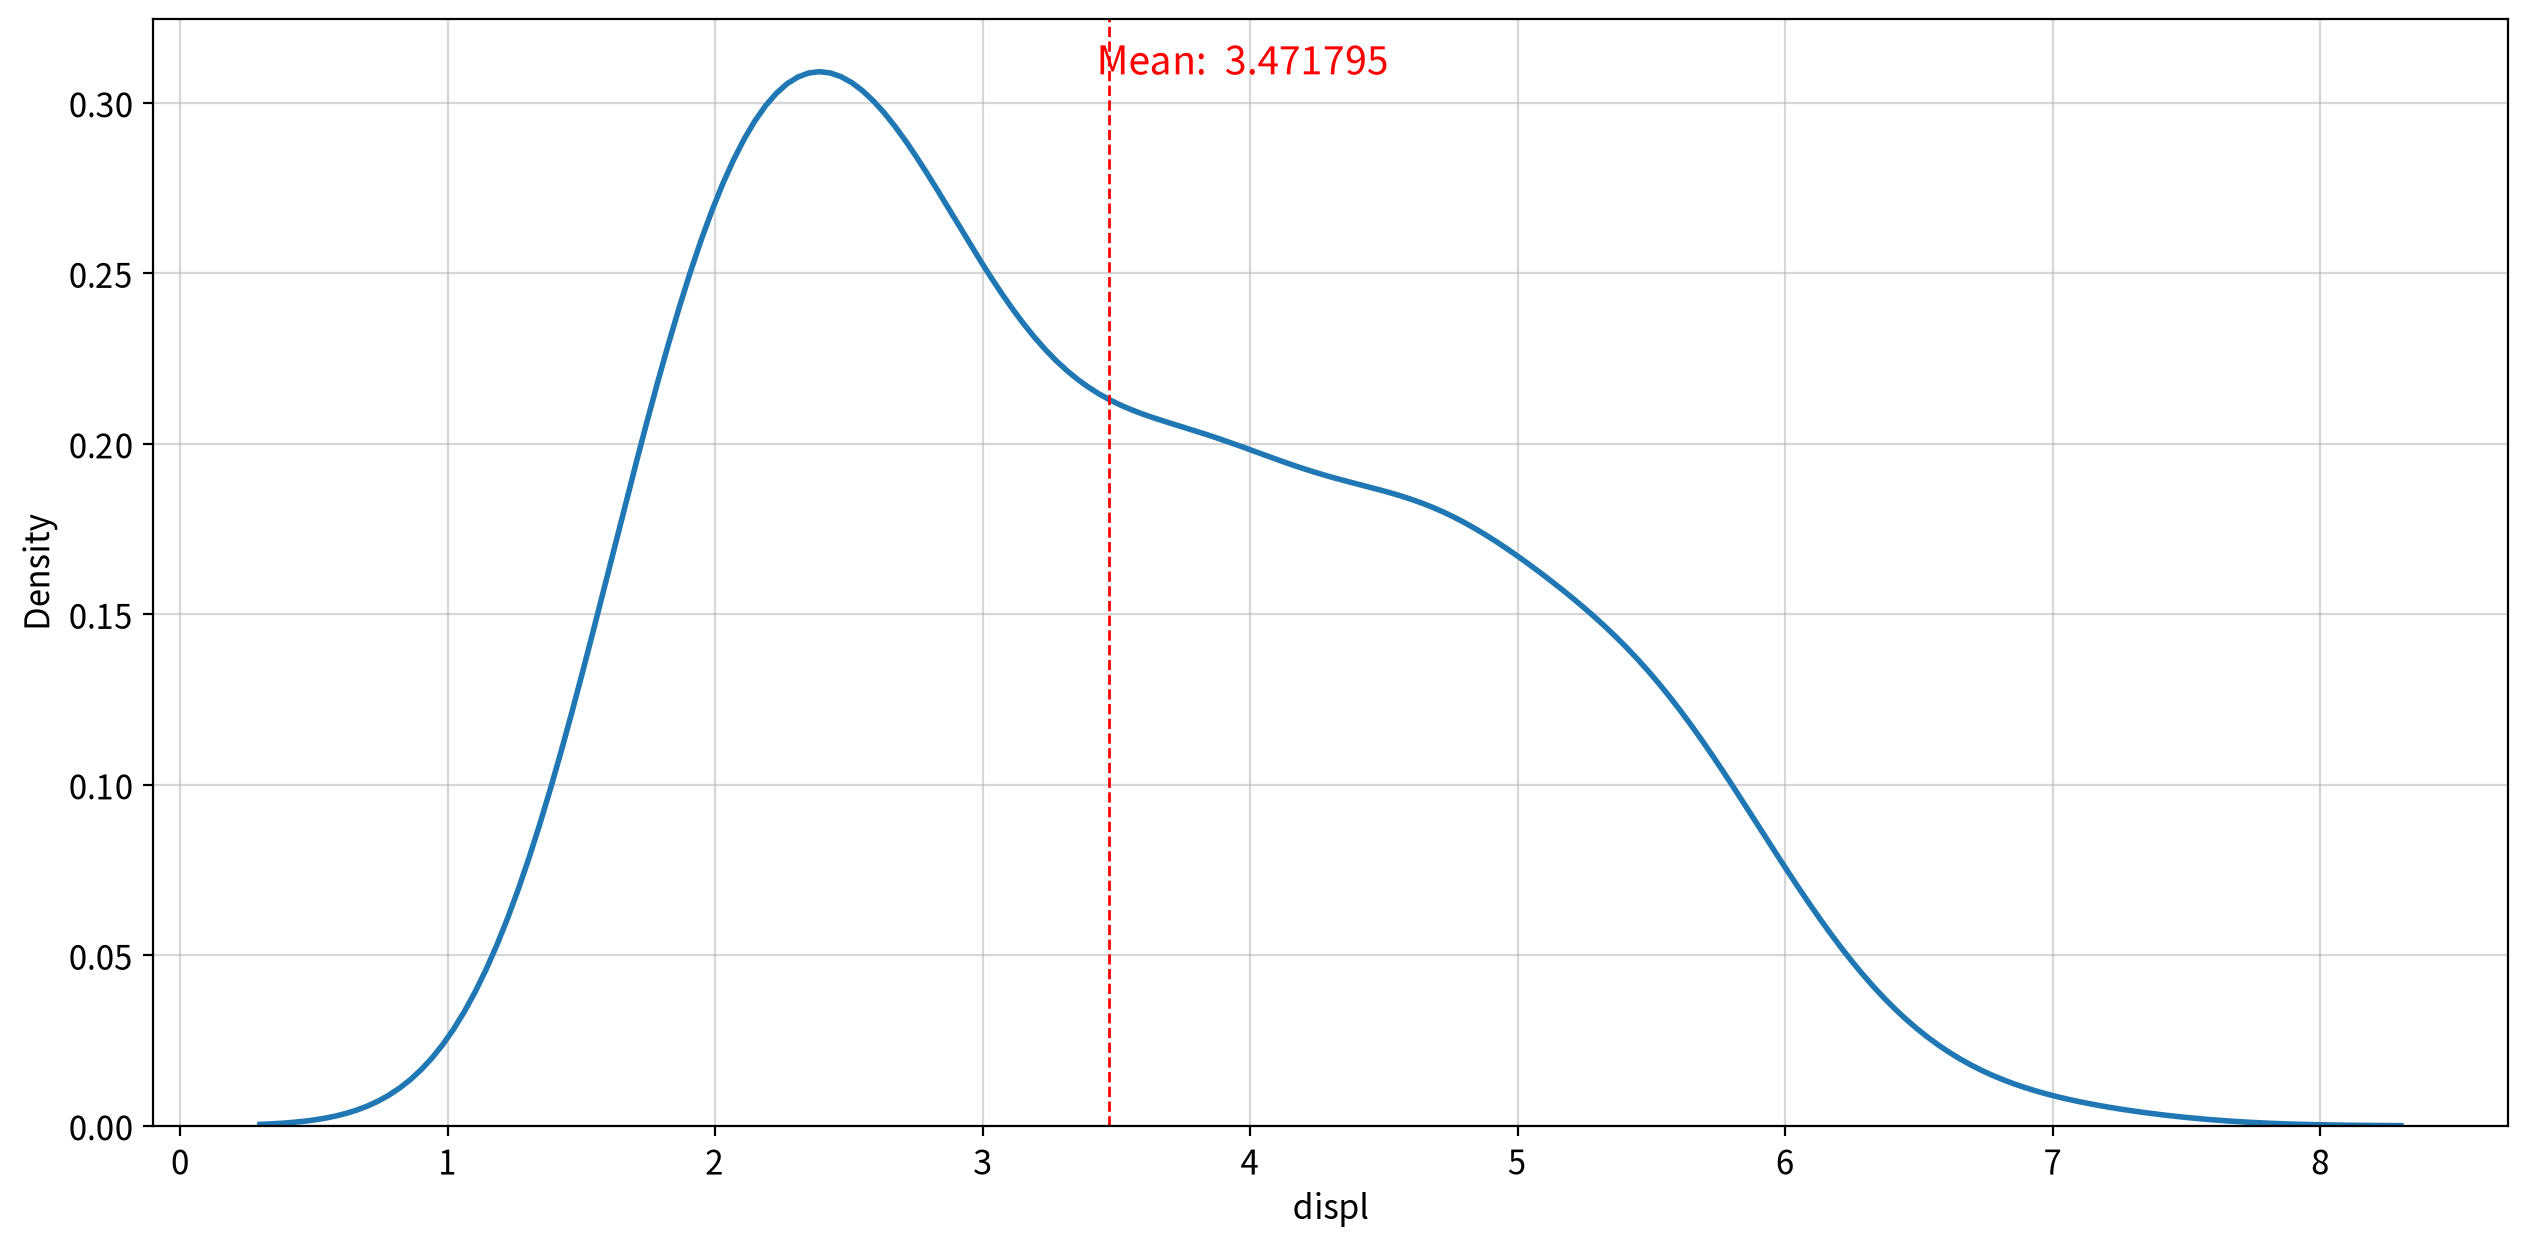

In [36]:
my_plot.kdeplot(data=df, x='displ', meanline=True)

## 정답
#### 3.4